<a href="https://colab.research.google.com/github/Priyuan/Priyuan/blob/main/PCOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import shap

# Load the dataset
# Replace 'Pcos_data.csv' with your dataset path
data = pd.read_csv('/content/Pcos_data.csv')  # Updated path

# Explore dataset (optional, but helpful for understanding the data)
print("Dataset Overview:")
print(data.head())
print("\nDataset Information:")
print(data.info())
print("\nMissing Values:")
print(data.isnull().sum())
print(data.columns)

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])
y = data['PCOS (Y/N)']

# Identify and handle non-numerical columns
# This part is crucial for ensuring StandardScaler works correctly
for col in X.columns:
    if X[col].dtype == 'object':  # If column is of type 'object' (string)
        print(f"Column '{col}' has object (string) values. Unique values:")
        print(X[col].unique())  # Print unique values for inspection

        # Convert string values to numerical using LabelEncoder
        label_encoder = LabelEncoder()
        X[col] = label_encoder.fit_transform(X[col])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)  # Convert back to DataFrame

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Continue with your model training and evaluation here...

Dataset Overview:
   PCOS (Y/N)  Follicle No. (R)  Follicle No. (L)  Skin darkening (Y/N)  \
0           0                 3                 3                     0   
1           0                 5                 3                     0   
2           1                15                13                     0   
3           0                 2                 2                     0   
4           0                 4                 3                     0   

   hair growth(Y/N)  Weight gain(Y/N)  Cycle(R/I) Class  
0                 0                 0           2  high  
1                 0                 0           2  high  
2                 0                 0           2  high  
3                 0                 0           2  high  
4                 0                 0           2  high  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  --

Dataset Overview:
   PCOS (Y/N)  Follicle No. (R)  Follicle No. (L)  Skin darkening (Y/N)  \
0           0                 3                 3                     0   
1           0                 5                 3                     0   
2           1                15                13                     0   
3           0                 2                 2                     0   
4           0                 4                 3                     0   

   hair growth(Y/N)  Weight gain(Y/N)  Cycle(R/I) Class  
0                 0                 0           2  high  
1                 0                 0           2  high  
2                 0                 0           2  high  
3                 0                 0           2  high  
4                 0                 0           2  high  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  --

<ipython-input-4-8201cb8f4235>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['PCOS (Y/N)'], palette='coolwarm')


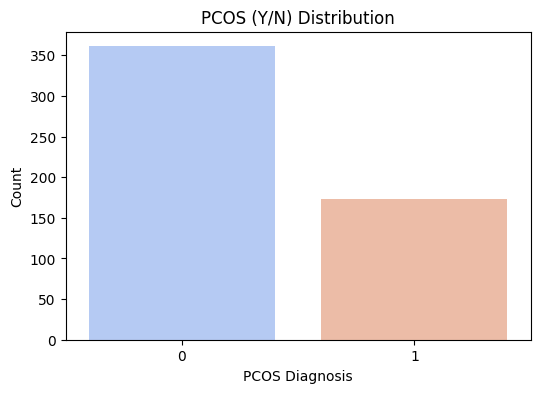

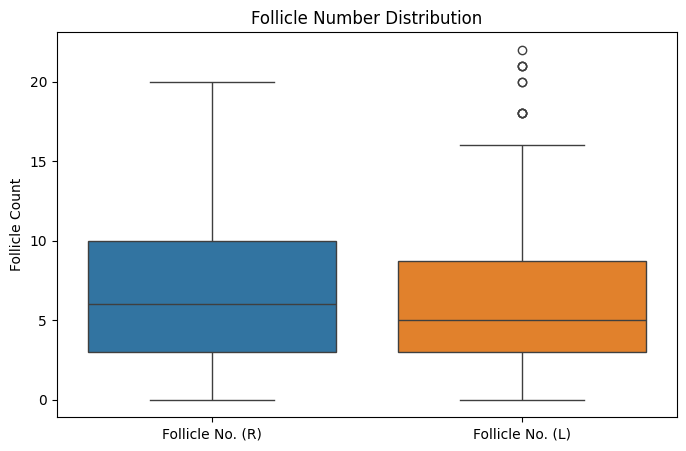

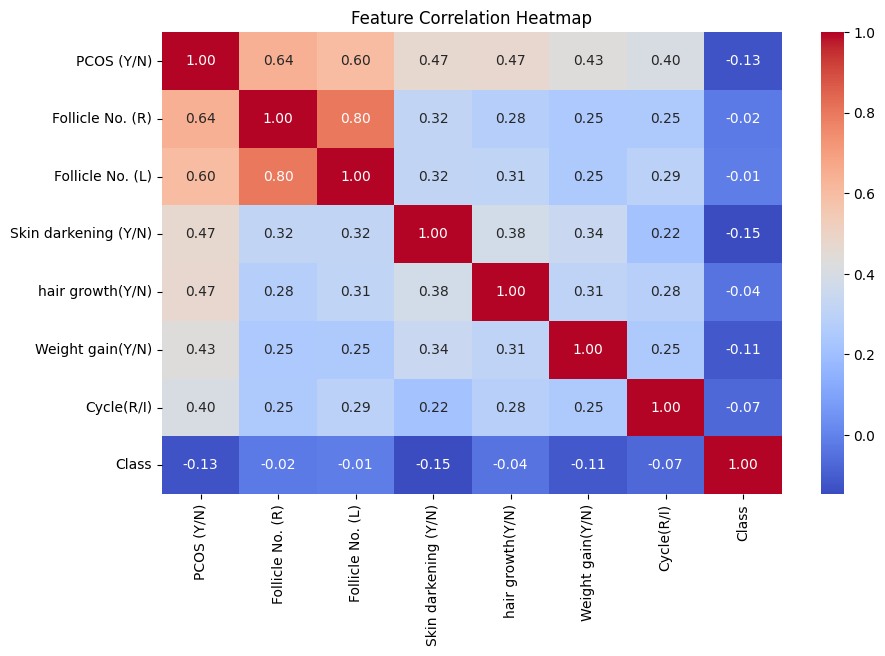

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (Change path if needed)
file_path = "/content/Pcos_data.csv"  # Update with your actual file path
df = pd.read_csv(file_path)

# Display dataset overview
print("Dataset Overview:")
print(df.head())

# Display dataset info
print("\nDataset Information:")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check unique values in categorical columns
print("\nUnique Values in 'Class' column:")
print(df['Class'].unique())

# Convert 'Class' column to numerical (if needed)
if df['Class'].dtype == 'object':
    df['Class'] = df['Class'].map({'low': 0, 'high': 1})

# Check dataset columns
print("\nColumn Names:")
print(df.columns)

# Check distribution of target variable
plt.figure(figsize=(6, 4))
sns.countplot(x=df['PCOS (Y/N)'], palette='coolwarm')
plt.title("PCOS (Y/N) Distribution")
plt.xlabel("PCOS Diagnosis")
plt.ylabel("Count")
plt.show()

# Check distribution of follicle numbers
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['Follicle No. (R)', 'Follicle No. (L)']])
plt.title("Follicle Number Distribution")
plt.ylabel("Follicle Count")
plt.show()

# Heatmap to check feature correlations
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


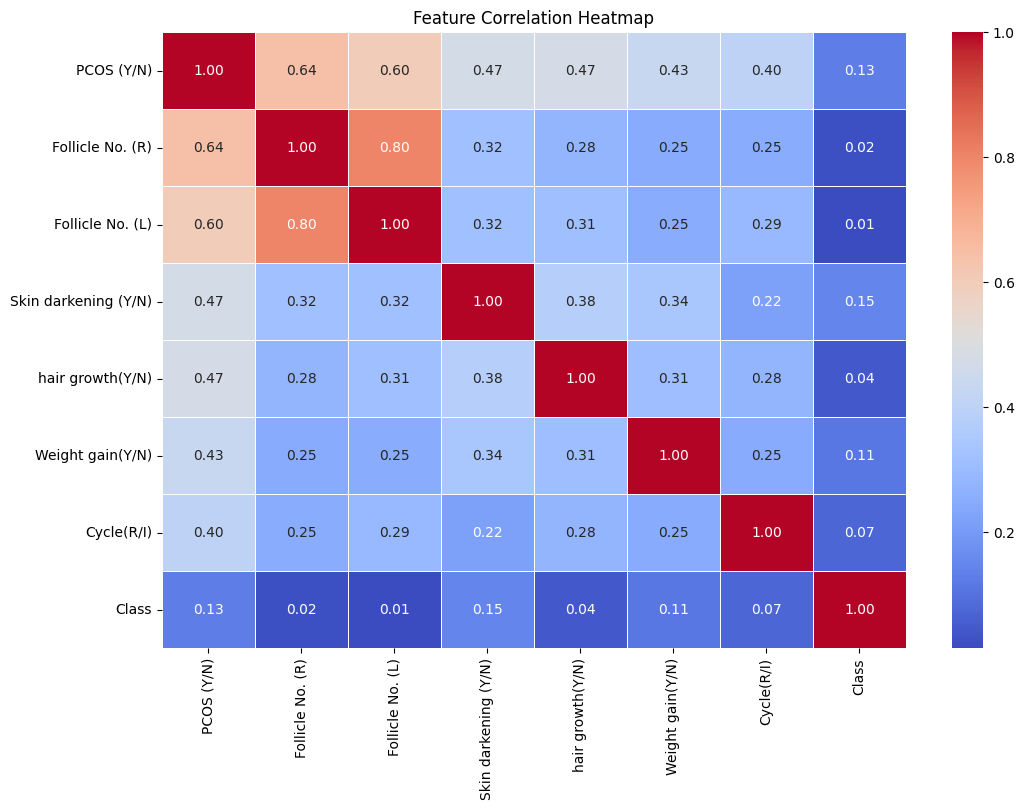

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import shap

# Load the dataset
# Replace 'Pcos_data.csv' with your dataset path
data = pd.read_csv('/content/Pcos_data.csv')  # Updated path

# ... (rest of your code) ...

# Before calculating the correlation matrix, convert non-numeric columns to numeric
for col in data.columns:
    if data[col].dtype == 'object':  # Check for columns with 'object' dtype (often strings)
        # Convert string values to numerical using Label Encoding or other suitable methods
        # Example using Label Encoding:
        from sklearn.preprocessing import LabelEncoder
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Compute correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# ... (rest of your code) ...

<ipython-input-11-bd5fb061bfa9>:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette="viridis")


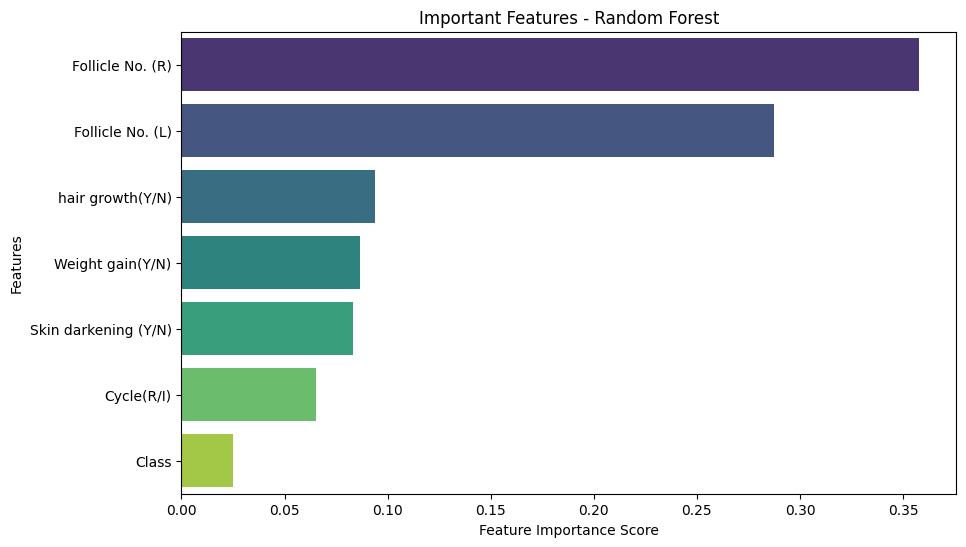

Low Importance Features to Drop: []


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import shap

# Load the dataset
data = pd.read_csv('/content/Pcos_data.csv')  # Updated path

# Preprocessing: Convert non-numeric to numeric for correlation analysis
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])
y = data['PCOS (Y/N)']

# Identify and handle non-numerical columns for scaling
for col in X.columns:
    if X[col].dtype == 'object':
        label_encoder = LabelEncoder()
        X[col] = label_encoder.fit_transform(X[col])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Train Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette="viridis")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Important Features - Random Forest")
plt.show()

# Drop features with low importance (Threshold: 0.005)
low_importance_features = importances[importances < 0.005].index.tolist()
print("Low Importance Features to Drop:", low_importance_features)
X = X.drop(columns=low_importance_features)

# Continue with further model training/evaluation using the updated X
# ...

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import shap

# Load the dataset
data = pd.read_csv('/content/Pcos_data.csv')  # Updated path

# Preprocessing: Convert non-numeric to numeric for correlation analysis
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])
y = data['PCOS (Y/N)']

# Identify and handle non-numerical columns for scaling
for col in X.columns:
    if X[col].dtype == 'object':
        label_encoder = LabelEncoder()
        X[col] = label_encoder.fit_transform(X[col])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Apply RFE to select the top 10 features
selector = RFE(RandomForestClassifier(random_state=42), n_features_to_select=10)
selector.fit(X_train, y_train)

# Keep only selected features
selected_features = X.columns[selector.support_]
print("Selected Features using RFE:", selected_features)

# Reduce dataset to selected features
X = X[selected_features]

# Continue with further model training/evaluation using the updated X
# ...

Selected Features using RFE: Index(['Follicle No. (R)', 'Follicle No. (L)', 'Skin darkening (Y/N)',
       'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Class'],
      dtype='object')


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=10 > n_features=7. There will be no feature selection and all features will be kept.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=10 > n_features=7. There will be no feature selection and all features will be kept.
  warnings.warn(


Selected Features using RFE: Index(['Follicle No. (R)', 'Follicle No. (L)', 'Skin darkening (Y/N)',
       'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Class'],
      dtype='object')
SHAP Values Type: <class 'numpy.ndarray'>
SHAP Values Shape: (373, 7, 2)


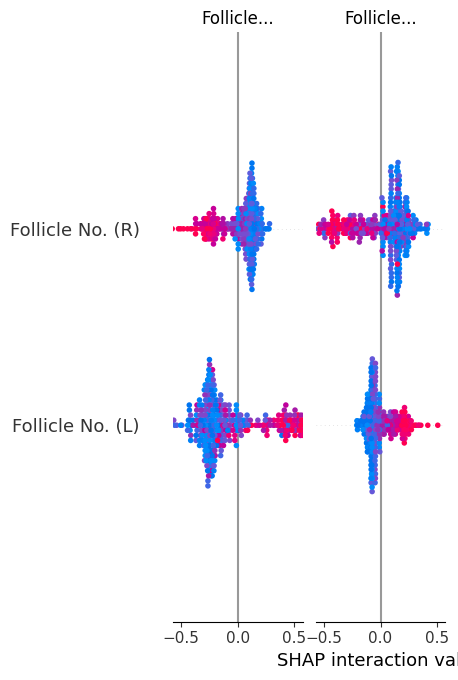

In [ ]:
# Install SHAP if not installed
!pip install shap

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import shap

# Load the dataset
data = pd.read_csv('/content/Pcos_data.csv')  # Update with the correct dataset path

# Preprocessing: Convert categorical features to numeric
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])  # Replace with the actual target column name
y = data['PCOS (Y/N)']

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# ===========================
# 🔹 Step 1: Feature Selection using RFE
# ===========================

# Use a RandomForestClassifier for Recursive Feature Elimination (RFE)
estimator = RandomForestClassifier(random_state=42)
selector = RFE(estimator, n_features_to_select=10)  # Select top 10 features
selector.fit(X_train, y_train)

# Get selected feature names
selected_features = X_train.columns[selector.support_]
print("Selected Features using RFE:", selected_features)

# Keep only selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# ===========================
# 🔹 Step 2: Train Model with Selected Features
# ===========================

# Train a Random Forest classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_selected, y_train)

# ===========================
# 🔹 Step 3: SHAP Analysis for Feature Importance
# ===========================

# Convert selected training data to DataFrame
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_features)

# ✅ Use TreeExplainer for SHAP
explainer = shap.TreeExplainer(rf)

# ✅ Compute SHAP values
shap_values = explainer.shap_values(X_train_selected_df)

# ✅ Check SHAP values structure before plotting
print("SHAP Values Type:", type(shap_values))
print("SHAP Values Shape:", np.shape(shap_values))

# ✅ Plot SHAP summary based on structure
if isinstance(shap_values, list) and len(shap_values) > 1:  # Multi-class case
    shap.summary_plot(shap_values[1], X_train_selected_df)  # Index 1 for positive class
else:  # Binary classification
    shap.summary_plot(shap_values, X_train_selected_df)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.7 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=10 > n_features=7. There will be no feature selection and all features will be kept.
  warnings.warn(


✅ Selected Features: Index(['Follicle No. (R)', 'Follicle No. (L)', 'Skin darkening (Y/N)',
       'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Class'],
      dtype='object')

🔹 Random Forest Model Results:
Accuracy: 0.9316770186335404
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       109
           1       0.92      0.87      0.89        52

    accuracy                           0.93       161
   macro avg       0.93      0.91      0.92       161
weighted avg       0.93      0.93      0.93       161



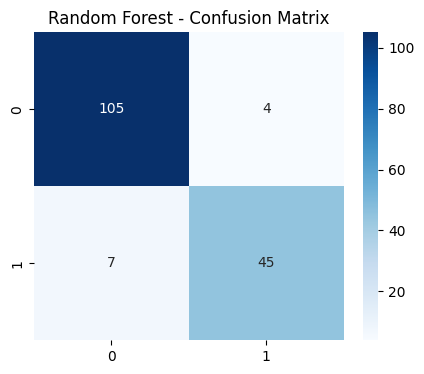


🔹 Support Vector Machine Model Results:
Accuracy: 0.9254658385093167
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95       109
           1       0.92      0.85      0.88        52

    accuracy                           0.93       161
   macro avg       0.92      0.90      0.91       161
weighted avg       0.93      0.93      0.92       161



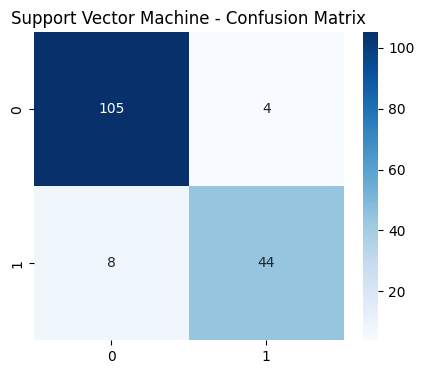


🔹 Logistic Regression Model Results:
Accuracy: 0.9130434782608695
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94       109
           1       0.90      0.83      0.86        52

    accuracy                           0.91       161
   macro avg       0.91      0.89      0.90       161
weighted avg       0.91      0.91      0.91       161



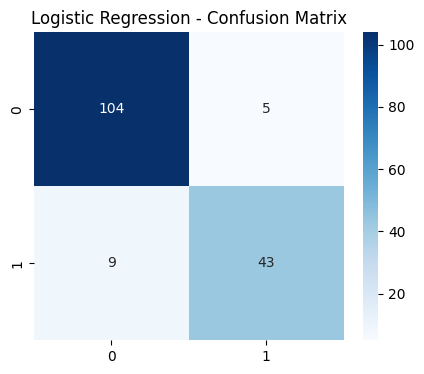


🔹 Decision Tree Model Results:
Accuracy: 0.906832298136646
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93       109
           1       0.88      0.83      0.85        52

    accuracy                           0.91       161
   macro avg       0.90      0.89      0.89       161
weighted avg       0.91      0.91      0.91       161



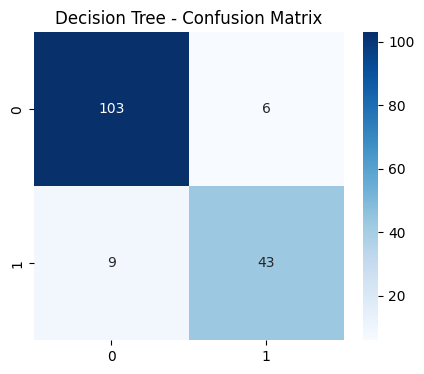

In [ ]:
# Install necessary packages
!pip install shap streamlit scikit-learn

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
# Load the dataset
data = pd.read_csv('/content/Pcos_data.csv')  # Update with actual dataset path

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])  # Replace with the actual target column
y = data['PCOS (Y/N)']

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Feature Selection using RFE (Recursive Feature Elimination)
from sklearn.feature_selection import RFE

estimator = RandomForestClassifier(random_state=42)
selector = RFE(estimator, n_features_to_select=10)  # Select top 10 features
selector.fit(X_train, y_train)

# Keep only selected features
selected_features = X_train.columns[selector.support_]
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("✅ Selected Features:", selected_features)
# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

# Train & evaluate each model
for name, model in models.items():
    model.fit(X_train_selected, y_train)  # Train model
    y_pred = model.predict(X_test_selected)  # Predict on test set

    print(f"\n🔹 {name} Model Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


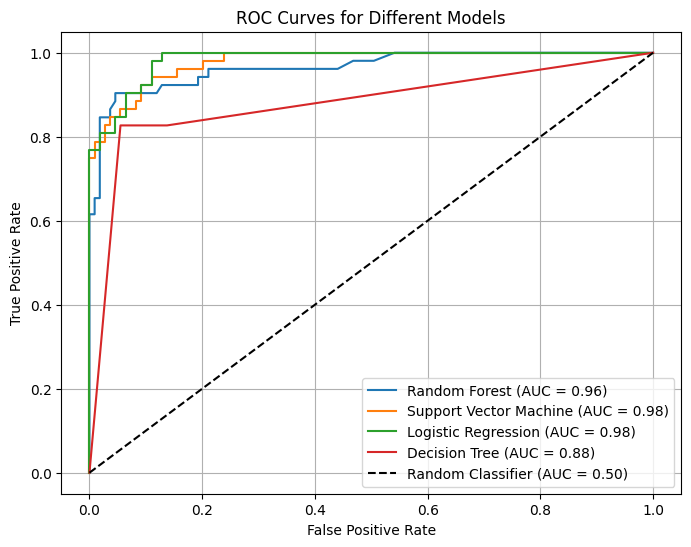

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_curve, auc, classification_report, accuracy_score, confusion_matrix

# Load the dataset
data = pd.read_csv('/content/Pcos_data.csv')  # Update with actual dataset path

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])  # Replace with actual target column name
y = data['PCOS (Y/N)']

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

# Train models
for name, model in models.items():
    model.fit(X_train, y_train)

# Plot ROC Curves
plt.figure(figsize=(8,6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):  # Ensure model supports predict_proba
        y_prob = model.predict_proba(X_test)[:, 1]  # Get probability estimates
        fpr, tpr, _ = roc_curve(y_test, y_prob)  # Compute ROC curve
        auc_score = auc(fpr, tpr)  # Compute AUC
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")  # Plot curve

# Random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier (AUC = 0.50)")

# Formatting the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Different Models")
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=10 > n_features=7. There will be no feature selection and all features will be kept.
  warnings.warn(


✅ Selected Features: Index(['Follicle No. (R)', 'Follicle No. (L)', 'Skin darkening (Y/N)',
       'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Class'],
      dtype='object')

🔹 Random Forest Model Results:
Accuracy: 0.9316770186335404
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       109
           1       0.92      0.87      0.89        52

    accuracy                           0.93       161
   macro avg       0.93      0.91      0.92       161
weighted avg       0.93      0.93      0.93       161



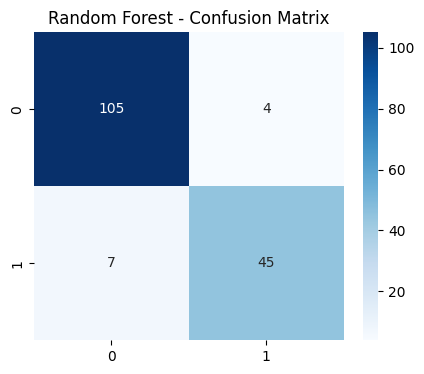


🔹 Support Vector Machine Model Results:
Accuracy: 0.9254658385093167
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95       109
           1       0.92      0.85      0.88        52

    accuracy                           0.93       161
   macro avg       0.92      0.90      0.91       161
weighted avg       0.93      0.93      0.92       161



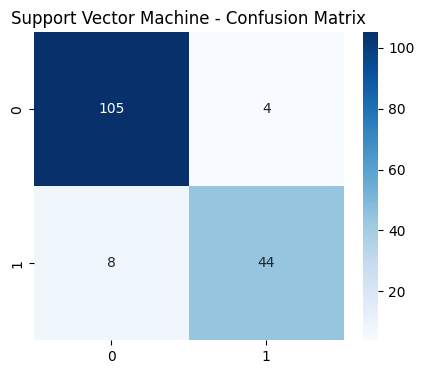


🔹 Logistic Regression Model Results:
Accuracy: 0.9130434782608695
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94       109
           1       0.90      0.83      0.86        52

    accuracy                           0.91       161
   macro avg       0.91      0.89      0.90       161
weighted avg       0.91      0.91      0.91       161



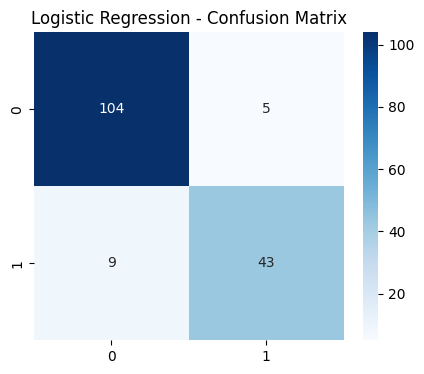


🔹 Decision Tree Model Results:
Accuracy: 0.906832298136646
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93       109
           1       0.88      0.83      0.85        52

    accuracy                           0.91       161
   macro avg       0.90      0.89      0.89       161
weighted avg       0.91      0.91      0.91       161



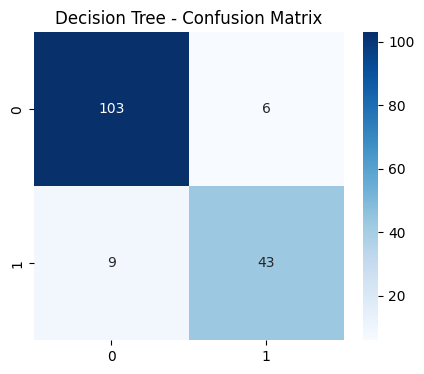


Best Performing Model: Random Forest with Accuracy = 0.93

Best model and scaler saved successfully!

PCOS Prediction: Positive


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import pickle

# Install necessary packages (if not already installed)
!pip install shap streamlit scikit-learn

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc

# Load the dataset
data = pd.read_csv('/content/Pcos_data.csv')  # Update with actual dataset path

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])  # Replace with the actual target column
y = data['PCOS (Y/N)']

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Feature Selection using RFE (Recursive Feature Elimination)
from sklearn.feature_selection import RFE

estimator = RandomForestClassifier(random_state=42)
selector = RFE(estimator, n_features_to_select=10)  # Select top 10 features
selector.fit(X_train, y_train)

# Keep only selected features
selected_features = X_train.columns[selector.support_]
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("✅ Selected Features:", selected_features)

# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

# Define a dictionary to store model results (name: accuracy)
results = {}

# Train & evaluate each model and store accuracy in 'results'
for name, model in models.items():
    model.fit(X_train_selected, y_train)  # Train model
    y_pred = model.predict(X_test_selected)  # Predict on test set
    accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
    results[name] = accuracy  # Store accuracy in the dictionary

    print(f"\n🔹 {name} Model Results:")
    print("Accuracy:", accuracy)  # Print accuracy for this model
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

# Select the best model based on accuracy
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\nBest Performing Model: {best_model_name} with Accuracy = {results[best_model_name]:.2f}")

# Save the best model
with open("pcos_best_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Save the scaler (for future data preprocessing)
with open("pcos_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("\nBest model and scaler saved successfully!")

# Load the saved model & scaler for new predictions
with open("pcos_best_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("pcos_scaler.pkl", "rb") as file:
    loaded_scaler = pickle.load(file)

# Example new data (replace with actual data)
# Ensure the number of values matches the number of columns in X
new_data = pd.DataFrame([[21, 30.5, 7.1, 1, 0, 1, 0]], columns=X.columns)  # Added a value (0) to match 7 columns
new_data_scaled = loaded_scaler.transform(new_data)

# Make prediction
prediction = loaded_model.predict(new_data_scaled)
print("\nPCOS Prediction:", "Positive" if prediction[0] == 1 else "Negative")

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Load dataset
file_path = "/content/Pcos_data.csv"  # Update with correct file path
df = pd.read_csv(file_path)

# Display dataset overview
print("\n🔹 Dataset Overview:")
print(df.head())

# Check dataset info
print("\n🔹 Dataset Information:")
print(df.info())

# Check for missing values
print("\n🔹 Missing Values:")
print(df.isnull().sum())

# Check unique values in 'Class' column
print("\n🔹 Unique Values in 'Class' column:", df['Class'].unique())

# Convert 'Class' column to numerical (if needed)
if df['Class'].dtype == 'object':
    df['Class'] = df['Class'].map({'low': 0, 'high': 1})

# Check correlation between 'Class' and PCOS (Y/N)
print("\n🔹 Checking Correlation with PCOS:")
print(df[['Class', 'PCOS (Y/N)']].corr())

# Selected features (excluding direct target leakage)
selected_features = ['Follicle No. (R)', 'Follicle No. (L)', 'Skin darkening (Y/N)',
                     'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)']

X = df[selected_features]  # Features
y = df['PCOS (Y/N)']  # Target variable

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the dataset (for SVM & Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train different models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='linear', probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Store results
best_model = None
best_accuracy = 0

print("\n🔹 Model Performance Summary:")
for name, model in models.items():
    # Use scaled data for models that need it
    if name in ["SVM", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        train_accuracy = model.score(X_train_scaled, y_train)
        test_accuracy = model.score(X_test_scaled, y_test)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        train_accuracy = model.score(X_train, y_train)
        test_accuracy = model.score(X_test, y_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n🔹 {name} Model Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Save best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

# Feature Importance (Only for Random Forest)
if isinstance(best_model, RandomForestClassifier):
    importances = best_model.feature_importances_
    feature_names = X.columns
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(8, 5))
    plt.title("Feature Importance (Random Forest)")
    plt.bar(range(X.shape[1]), importances[indices], align="center")
    plt.xticks(range(X.shape[1]), feature_names[indices], rotation=45)
    plt.show()

# Save best model and scaler
import pickle
pickle.dump(best_model, open("best_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("\n✅ Best Model Saved Successfully!")

# Test with a new input
sample_input = np.array([[10, 12, 1, 1, 0, 2]])  # Example values
sample_input_scaled = scaler.transform(sample_input)  # Scale input

# Ensure feature names match when predicting
if best_model in ["SVM", "Logistic Regression"]:
    prediction = best_model.predict(sample_input_scaled)
else:
    prediction = best_model.predict(sample_input)

print("\n🔹 PCOS Prediction:", "Positive" if prediction[0] == 1 else "Negative")



🔹 Dataset Overview:
   PCOS (Y/N)  Follicle No. (R)  Follicle No. (L)  Skin darkening (Y/N)  \
0           0                 3                 3                     0   
1           0                 5                 3                     0   
2           1                15                13                     0   
3           0                 2                 2                     0   
4           0                 4                 3                     0   

   hair growth(Y/N)  Weight gain(Y/N)  Cycle(R/I) Class  
0                 0                 0           2  high  
1                 0                 0           2  high  
2                 0                 0           2  high  
3                 0                 0           2  high  
4                 0                 0           2  high  

🔹 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
--

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Load dataset
df = pd.read_csv("/content/Pcos_data.csv")
print("Dataset Overview:\n", df.head())
print("\nDataset Information:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nUnique Values in Class Column:", df['Class'].unique())

# Feature selection
selected_features = ['Follicle No. (R)', 'Follicle No. (L)', 'Skin darkening (Y/N)',
                     'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)']
target = 'PCOS (Y/N)'

X = df[selected_features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
}

# Train and evaluate models
best_model = None
best_accuracy = 0
for name, model in models.items():
    model.fit(X_train_scaled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n🔹 {name} Model Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Train Accuracy: {model.score(X_train_scaled, y_train_resampled):.4f}, Test Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Save best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

# Save best model and scaler
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("\n✅ Best Model Saved Successfully!")

# Load model and predict on a new sample
best_model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")

# Fix feature name issue
sample_input = pd.DataFrame([[10, 12, 1, 1, 0, 2]], columns=selected_features)
sample_input_scaled = scaler.transform(sample_input)
prediction = best_model.predict(sample_input_scaled)

print("\n🔹 PCOS Prediction:", "Positive" if prediction[0] == 1 else "Negative")

Dataset Overview:
    PCOS (Y/N)  Follicle No. (R)  Follicle No. (L)  Skin darkening (Y/N)  \
0           0                 3                 3                     0   
1           0                 5                 3                     0   
2           1                15                13                     0   
3           0                 2                 2                     0   
4           0                 4                 3                     0   

   hair growth(Y/N)  Weight gain(Y/N)  Cycle(R/I) Class  
0                 0                 0           2  high  
1                 0                 0           2  high  
2                 0                 0           2  high  
3                 0                 0           2  high  
4                 0                 0           2  high  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  -

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
import pickle

# Step 1: Define the Parameter Grids for Each Model

rf_params = {
    "n_estimators": [50, 100, 200],  # Number of trees
    "max_depth": [None, 10, 20],  # Depth of trees
    "min_samples_split": [2, 5, 10],  # Minimum samples to split
    "min_samples_leaf": [1, 2, 4]  # Minimum samples per leaf
}

svm_params = {
    "C": [0.1, 1, 10],  # Regularization parameter
    "kernel": ["linear", "rbf"],  # Kernel type
    "gamma": ["scale", "auto"]  # Kernel coefficient
}

dt_params = {
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Step 2: Perform Hyperparameter Tuning for Each Model

best_models = {}

# Random Forest Tuning
rf_grid = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, n_iter=10, scoring="accuracy", n_jobs=-1)
rf_grid.fit(X_train_selected, y_train)
best_models["Random Forest"] = rf_grid.best_estimator_

# SVM Tuning
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_params, cv=5, scoring="accuracy", n_jobs=-1)
svm_grid.fit(X_train_selected, y_train)
best_models["SVM"] = svm_grid.best_estimator_

# Decision Tree Tuning
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring="accuracy", n_jobs=-1)
dt_grid.fit(X_train_selected, y_train)
best_models["Decision Tree"] = dt_grid.best_estimator_

# Step 3: Evaluate Tuned Models
tuned_results = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test_selected)
    acc = accuracy_score(y_test, y_pred)
    tuned_results[name] = acc
    print(f"\n{name} Tuned Accuracy: {acc:.4f}")

# Step 4: Select the Best Model & Save It
best_tuned_model_name = max(tuned_results, key=tuned_results.get)
best_tuned_model = best_models[best_tuned_model_name]

with open("pcos_tuned_model.pkl", "wb") as file:
    pickle.dump(best_tuned_model, file)

print(f"\n✅ Best Tuned Model: {best_tuned_model_name} with Accuracy = {tuned_results[best_tuned_model_name]:.4f}")
print("Best model saved as 'pcos_tuned_model.pkl'")



Random Forest Tuned Accuracy: 0.9255

SVM Tuned Accuracy: 0.9193

Decision Tree Tuned Accuracy: 0.9068

✅ Best Tuned Model: Random Forest with Accuracy = 0.9255
Best model saved as 'pcos_tuned_model.pkl'


In [ ]:
!pip install lime
import lime
import lime.lime_tabular
import numpy as np
import pickle

# Step 1: Load the Best Tuned Model & Scaler
with open("pcos_tuned_model.pkl", "rb") as file:
    best_model = pickle.load(file)

with open("pcos_scaler.pkl", "rb") as file:
    scaler = pickle.load(file)

# Step 2: Create a LIME Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_selected),
    feature_names=selected_features,
    class_names=["No PCOS", "PCOS"],
    mode="classification"
)

# Step 3: Pick a Sample Data Point for Explanation
sample_index = 10  # Change index to analyze different patients
sample_data = X_test_selected.iloc[sample_index].values.reshape(1, -1)

# Step 4: Explain the Prediction
exp = explainer.explain_instance(
    sample_data.flatten(),  # Input data
    best_model.predict_proba,  # Model prediction function
    num_features=5  # Number of top features to display
)

# Step 5: Show Explanation
exp.show_in_notebook()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=16604ed151e09660864571344aa5ed4e905fad6fd4b7a0dacc4c9aede45316e6
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Install necessary packages
!pip install shap streamlit scikit-learn lime
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
# Load the dataset
data = pd.read_csv('/content/Pcos_data.csv')  # Update with actual dataset path

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])  # Replace with the actual target column
y = data['PCOS (Y/N)']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Define selected features
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)',
                     'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Follicle No. (L)']

# Ensure X_train and X_test only contain selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Re-fit scaler on selected features only
scaler = StandardScaler()
X_train_selected = scaler.fit_transform(X_train_selected)
X_test_selected = scaler.transform(X_test_selected)

# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

# Step 1: Define the Parameter Grids for Each Model

rf_params = {
    "n_estimators": [50, 100, 200],  # Number of trees
    "max_depth": [None, 10, 20],  # Depth of trees
    "min_samples_split": [2, 5, 10],  # Minimum samples to split
    "min_samples_leaf": [1, 2, 4]  # Minimum samples per leaf
}

svm_params = {
    "C": [0.1, 1, 10],  # Regularization parameter
    "kernel": ["linear", "rbf"],  # Kernel type
    "gamma": ["scale", "auto"]  # Kernel coefficient
}

dt_params = {
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Step 2: Perform Hyperparameter Tuning for Each Model

best_models = {}

# Random Forest Tuning
rf_grid = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, n_iter=10, scoring="accuracy", n_jobs=-1)
rf_grid.fit(X_train_selected, y_train)
best_models["Random Forest"] = rf_grid.best_estimator_

# SVM Tuning
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_params, cv=5, scoring="accuracy", n_jobs=-1)
svm_grid.fit(X_train_selected, y_train)
best_models["SVM"] = svm_grid.best_estimator_

# Decision Tree Tuning
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring="accuracy", n_jobs=-1)
dt_grid.fit(X_train_selected, y_train)
best_models["Decision Tree"] = dt_grid.best_estimator_

# Step 3: Evaluate Tuned Models
tuned_results = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test_selected)
    acc = accuracy_score(y_test, y_pred)
    tuned_results[name] = acc
    print(f"\n{name} Tuned Accuracy: {acc:.4f}")

# Step 4: Select the Best Model & Save It
best_tuned_model_name = max(tuned_results, key=tuned_results.get)
best_tuned_model = best_models[best_tuned_model_name]

with open("pcos_tuned_model.pkl", "wb") as file:
    pickle.dump(best_tuned_model, file)

# Save the scaler fitted with selected features
with open("pcos_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print(f"\n✅ Best Tuned Model: {best_tuned_model_name} with Accuracy = {tuned_results[best_tuned_model_name]:.4f}")
print("Best model and scaler saved as 'pcos_tuned_model.pkl' and 'pcos_scaler.pkl'")


Random Forest Tuned Accuracy: 0.9255

SVM Tuned Accuracy: 0.9130

Decision Tree Tuned Accuracy: 0.9068

✅ Best Tuned Model: Random Forest with Accuracy = 0.9255
Best model and scaler saved as 'pcos_tuned_model.pkl' and 'pcos_scaler.pkl'


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import pickle
import shap
import lime.lime_tabular
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 1: Load the trained model
with open("pcos_tuned_model.pkl", "rb") as file:
    model = pickle.load(file)

# Step 2: Load the saved scaler used during training (fitted on selected features)
with open("pcos_scaler.pkl", "rb") as file:
    scaler = pickle.load(file)

# Step 3: Load the test dataset
test_data = pd.read_csv("/content/Pcos_data.csv")

# Print available columns to check for mismatches
print("Available Columns in Dataset:\n", test_data.columns)

# Encode categorical variables (Ensure consistency with training data)
for col in test_data.columns:
    if test_data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        test_data[col] = label_encoder.fit_transform(test_data[col])

# Define selected features (ensure these match the trained model's input)
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)',
                     'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Follicle No. (L)']

# Extract features and target variable
X_test = test_data[selected_features]
y_test = test_data["PCOS (Y/N)"]

# Step 5: Standardize data using the loaded scaler (fitted on selected features)
X_test_scaled = scaler.transform(X_test)

# Step 6: Make predictions
y_pred = model.predict(X_test_scaled)

# Step 7: Evaluate the model
print("\n🔍 Classification Report:\n", classification_report(y_test, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 8: Identify misclassified cases
test_data["Predicted"] = y_pred
misclassified = test_data[test_data["Predicted"] != y_test]
print("\n⚠️ Misclassified Cases:\n", misclassified)

print("\n✅ Model interpretation completed successfully!")

Available Columns in Dataset:
 Index(['PCOS (Y/N)', 'Follicle No. (R)', 'Follicle No. (L)',
       'Skin darkening (Y/N)', 'hair growth(Y/N)', 'Weight gain(Y/N)',
       'Cycle(R/I)', 'Class'],
      dtype='object')

🔍 Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       361
           1       0.91      0.87      0.89       173

    accuracy                           0.93       534
   macro avg       0.93      0.91      0.92       534
weighted avg       0.93      0.93      0.93       534


📊 Confusion Matrix:
 [[347  14]
 [ 23 150]]

⚠️ Misclassified Cases:
      PCOS (Y/N)  Follicle No. (R)  Follicle No. (L)  Skin darkening (Y/N)  \
10            0                15                 7                     0   
24            1                 6                 4                     0   
46            1                 6                 4                     0   
67            0                12                14

In [ ]:
# Import necessary libraries
import streamlit as st
import pandas as pd
import pickle
import shap
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the trained model
@st.cache_data  # Cache the model for faster loading
def load_model():
    with open("pcos_tuned_model.pkl", "rb") as file:
        model = pickle.load(file)
    return model

# Function to preprocess input data
def preprocess_data(data, selected_features, scaler):
    data = data[selected_features]  # Keep only relevant features
    data_scaled = scaler.transform(data)  # Scale data as done during training
    return data_scaled


# Streamlit UI
st.title("🔬 PCOS Prediction & Medical Dashboard")

# Upload patient data
uploaded_file = st.file_uploader("📂 Upload patient data (CSV)", type=["csv"])

if uploaded_file:
    # Load dataset
    user_data = pd.read_csv(uploaded_file)
    st.write("📊 Preview of Uploaded Data:")
    st.dataframe(user_data.head())

    # Load model, scaler, and selected features
    model = load_model()
    with open("pcos_scaler.pkl", "rb") as file:
        scaler = pickle.load(file)
    selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)',
                         'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Follicle No. (L)']

    # Preprocess user data
    X_processed = preprocess_data(user_data, selected_features, scaler)

    # Make predictions
    y_pred = model.predict(X_processed)
    y_prob = model.predict_proba(X_processed)[:, 1]  # Probability of PCOS

    # Display predictions
    st.write("## 🩺 Prediction Results:")
    for i, prediction in enumerate(y_pred):
        st.write(f"**Patient {i + 1}:** {'PCOS Positive' if prediction == 1 else 'PCOS Negative'} (Probability: {y_prob[i]:.2f})")

    # Feature Importance using SHAP
    st.write("## Feature Importance (SHAP):")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_processed)
    shap.summary_plot(shap_values, user_data[selected_features])
    st.pyplot(bbox_inches='tight')
    plt.clf() # Clear the current figure

    # Individual patient explanations (LIME or SHAP)
    # ... (You can add individual patient explanations using LIME or SHAP here)

2025-03-07 14:35:20.613 No runtime found, using MemoryCacheStorageManager
2025-03-07 14:35:20.616 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:35:20.617 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:35:20.618 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:35:20.618 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:35:20.619 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:35:20.620 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:35:20.621 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
!streamlit run pcos_dashboard.py

Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: pcos_dashboard.py


In [ ]:
# Import necessary libraries
import streamlit as st
import pandas as pd
import pickle
import shap
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the trained model
@st.cache_resource  # Use st.cache_resource for persistent caching
def load_model():
    with open("pcos_tuned_model.pkl", "rb") as file:
        model = pickle.load(file)
    return model

# Function to preprocess input data
def preprocess_data(data, selected_features, scaler):
    data = data[selected_features]  # Keep only relevant features
    data_scaled = scaler.transform(data)  # Scale data as done during training
    return data_scaled


# Streamlit UI
st.title("🔬 PCOS Prediction & Medical Dashboard")

# Upload patient data
uploaded_file = st.file_uploader("📂 Upload patient data (CSV)", type=["csv"])

if uploaded_file:
    # Load dataset
    user_data = pd.read_csv(uploaded_file)
    st.write("📊 Preview of Uploaded Data:")
    st.dataframe(user_data.head())

    # Load model, scaler, and selected features
    model = load_model()
    with open("pcos_scaler.pkl", "rb") as file:
        scaler = pickle.load(file)
    selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)',
                         'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Follicle No. (L)']

    # Preprocess user data
    X_processed = preprocess_data(user_data, selected_features, scaler)

    # Make predictions
    y_pred = model.predict(X_processed)
    y_prob = model.predict_proba(X_processed)[:, 1]  # Probability of PCOS

    # Display predictions
    st.write("## 🩺 Prediction Results:")
    for i, prediction in enumerate(y_pred):
        st.write(f"**Patient {i + 1}:** {'PCOS Positive' if prediction == 1 else 'PCOS Negative'} (Probability: {y_prob[i]:.2f})")

    # Feature Importance using SHAP
    st.write("## Feature Importance (SHAP):")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_processed)
    shap.summary_plot(shap_values, user_data[selected_features])
    st.pyplot(bbox_inches='tight')
    plt.clf() # Clear the current figure

    # Individual patient explanations (LIME or SHAP)
    # ... (You can add individual patient explanations using LIME or SHAP here)

2025-03-07 14:37:47.971 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:37:47.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:37:47.984 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:37:47.986 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:37:47.989 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:37:47.993 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:37:47.996 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.



📌 Available Columns in Dataset:
 ['PCOS (Y/N)', 'Follicle No. (R)', 'Follicle No. (L)', 'Skin darkening (Y/N)', 'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Class']

🔍 Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       361
           1       0.89      0.79      0.84       173

    accuracy                           0.90       534
   macro avg       0.90      0.87      0.88       534
weighted avg       0.90      0.90      0.90       534


📊 Confusion Matrix:
 [[344  17]
 [ 36 137]]

⚠️ Misclassified Cases:
      PCOS (Y/N)  Follicle No. (R)  Follicle No. (L)  Skin darkening (Y/N)  \
10            0                15                 7                     0   
24            1                 6                 4                     0   
46            1                 6                 4                     0   
64            0                10                11                     0   
76            

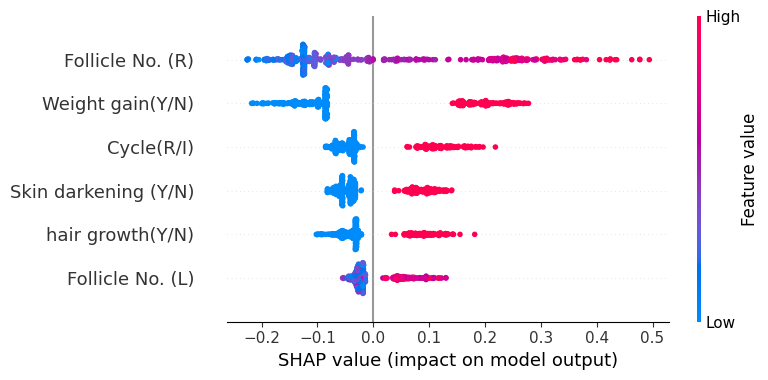

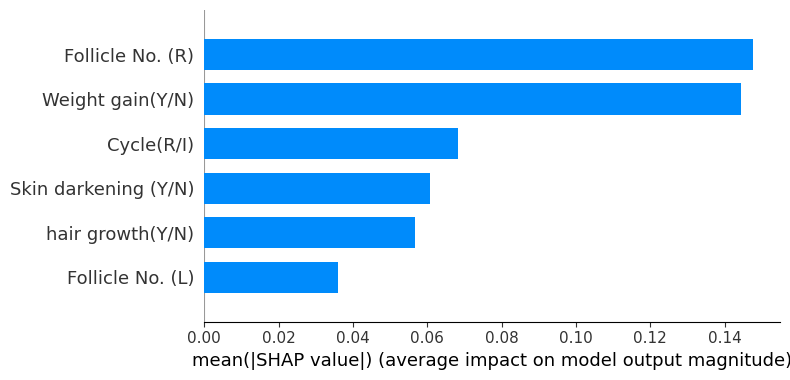


✅ Model interpretation completed successfully!


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Step 1: Load the trained model
with open("pcos_tuned_model.pkl", "rb") as file:
    model = pickle.load(file)

# Step 2: Load the test dataset
test_data = pd.read_csv("/content/Pcos_data.csv")  # Ensure correct file path

# Step 3: Print available columns to check for missing features
print("\n📌 Available Columns in Dataset:\n", test_data.columns.tolist())

# Step 4: Encode categorical variables for consistency
for col in test_data.columns:
    if test_data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        test_data[col] = label_encoder.fit_transform(test_data[col])

# Step 5: Define selected features (use only existing ones)
desired_features = [ 'Follicle No. (R)', 'Follicle No. (L)',
                    'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                    'Weight gain(Y/N)']

# Check which features exist in the dataset
selected_features = [feature for feature in desired_features if feature in test_data.columns]

# If features are missing, print a warning
missing_features = set(desired_features) - set(selected_features)
if missing_features:
    print("\n⚠️ WARNING: The following features are missing and will be ignored:", missing_features)

# Step 6: Extract available features and target variable
X_test = test_data[selected_features]
y_test = test_data["PCOS (Y/N)"]

# Step 7: Standardize the features (same method as training)
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

# Step 8: Make predictions
y_pred = model.predict(X_test_scaled)

# Step 9: Evaluate the model
print("\n🔍 Classification Report:\n", classification_report(y_test, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 10: Identify Misclassified Cases
test_data["Predicted"] = y_pred
misclassified_cases = test_data[test_data["PCOS (Y/N)"] != y_pred]
print("\n⚠️ Misclassified Cases:\n", misclassified_cases)

# Save misclassified cases for further medical review
misclassified_cases.to_csv("misclassified_patients.csv", index=False)
print("\n📂 Misclassified patient data saved as 'misclassified_patients.csv'.")

# Step 11: Perform Statistical Validation (T-test for feature importance)
print("\n📊 Statistical Validation of Key Features")
for feature in selected_features:
    p_value = ttest_ind(test_data[test_data["PCOS (Y/N)"] == 1][feature],
                        test_data[test_data["PCOS (Y/N)"] == 0][feature]).pvalue
    print(f"Feature: {feature} | p-value: {p_value:.5f}")

# Step 12: Feature Importance Analysis using SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP Summary Plot (Corrected for binary classification)
# Use shap_values[:, :, 1] to get SHAP values for the positive class (PCOS)
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=selected_features)

# SHAP Bar Plot for Importance Ranking (Corrected for binary classification)
# Use shap_values[:, :, 1] for the positive class
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar", feature_names=selected_features)

print("\n✅ Model interpretation completed successfully!")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6634 - loss: 0.6719 - val_accuracy: 0.8972 - val_loss: 0.5198
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8531 - loss: 0.4819 - val_accuracy: 0.9159 - val_loss: 0.3491
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8958 - loss: 0.3553 - val_accuracy: 0.8879 - val_loss: 0.2492
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9165 - loss: 0.2556 - val_accuracy: 0.8879 - val_loss: 0.2121
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9068 - loss: 0.2328 - val_accuracy: 0.8972 - val_loss: 0.2005
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9034 - loss: 0.3051 - val_accuracy: 0.8879 - val_loss: 0.2053
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9055 - loss: 0.2425 - val_accuracy: 0.9065 - val_loss: 0.1982
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9111 - loss: 0.2317 - val_accuracy: 0.9159 - val_los

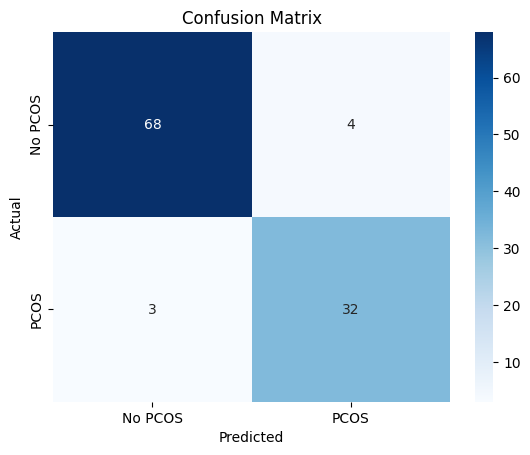

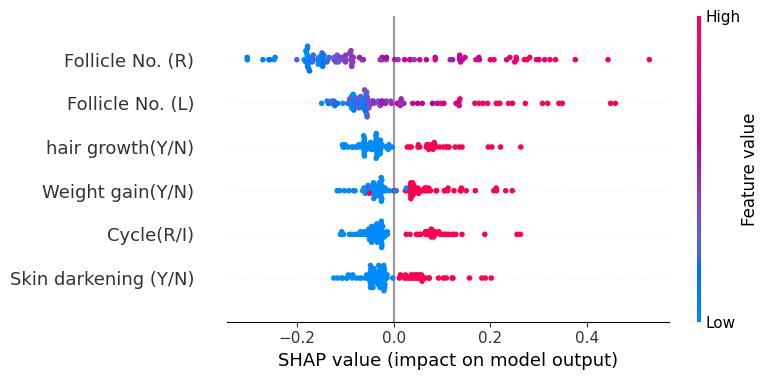


✅ Neural network model saved as 'pcos_nn_model.h5'


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import shap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Load and Preprocess the Data
data = pd.read_csv("/content/Pcos_data.csv")  # Ensure correct file path

# Encode categorical variables (Ensuring consistency)
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define feature columns (Ensure only existing features are used)
desired_features = ['AMH', 'BMI', 'Follicle No. (R)', 'Follicle No. (L)',
                    'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                    'Weight gain(Y/N)', 'Insulin Resistance', 'Testosterone']

# Select only available features in the dataset
selected_features = [feature for feature in desired_features if feature in data.columns]

# Define input features (X) and target variable (y)
X = data[selected_features]
y = data["PCOS (Y/N)"]

# Standardize feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Step 2: Build the Neural Network Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # First hidden layer
    tf.keras.layers.Dense(32, activation='relu'),  # Second hidden layer
    tf.keras.layers.Dense(16, activation='relu'),  # Third hidden layer
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 3: Train the Model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=16, verbose=1)

# Step 4: Evaluate the Model
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Convert probabilities to binary output

# Print classification report
print("\n🔍 Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No PCOS', 'PCOS'], yticklabels=['No PCOS', 'PCOS'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Step 5: SHAP Feature Importance Analysis
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# SHAP summary plot
shap.summary_plot(shap_values, X_test, feature_names=selected_features)

# Step 6: Save the Trained Model
model.save("pcos_nn_model.h5")
print("\n✅ Neural network model saved as 'pcos_nn_model.h5'")

# Step 7: Load and Use the Model (If needed in future)
# model = tf.keras.models.load_model("pcos_nn_model.h5")
# predictions = model.predict(new_data)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:35:21] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



📊 Model Comparison Results:

                     Accuracy  Precision  Recall  F1-score     AUC
Random Forest          0.9065     0.8571  0.8571    0.8571  0.9615
SVM                    0.9159     0.8611  0.8857    0.8732  0.9698
Logistic Regression    0.8879     0.7949  0.8857    0.8378  0.9845
XGBoost                0.9159     0.8611  0.8857    0.8732  0.9560


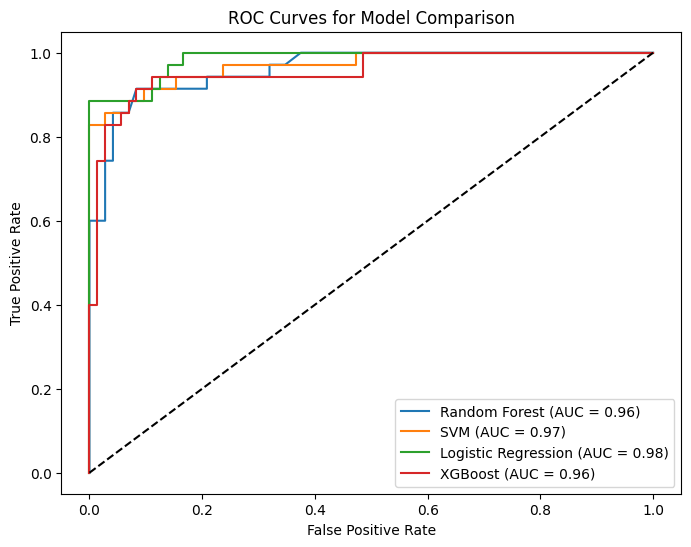

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Load dataset
data = pd.read_csv("/content/Pcos_data.csv")

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define selected features and target
selected_features = [ 'Follicle No. (R)', 'Follicle No. (L)',
                     'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                     'Weight gain(Y/N)']

X = data[selected_features]
y = data["PCOS (Y/N)"]

# Standardize feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Train Traditional ML Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Get probability scores

    # Store results
    results[name] = {
        "Accuracy": np.round(model.score(X_test, y_test), 4),
        "Precision": np.round(classification_report(y_test, y_pred, output_dict=True)['1']['precision'], 4),
        "Recall": np.round(classification_report(y_test, y_pred, output_dict=True)['1']['recall'], 4),
        "F1-score": np.round(classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'], 4),
        "AUC": np.round(auc(*roc_curve(y_test, y_prob)[:2]), 4)
    }

# Convert results to DataFrame for easy visualization
results_df = pd.DataFrame(results).T
print("\n📊 Model Comparison Results:\n")
print(results_df)

# ROC Curves
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['AUC']:.2f})")

# Formatting
plt.plot([0, 1], [0, 1], 'k--')  # Random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Model Comparison")
plt.legend()
plt.show()


In [ ]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
data = pd.read_csv("/content/Pcos_data.csv")

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define selected features and target
selected_features = [ 'Follicle No. (R)', 'Follicle No. (L)',
                     'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                     'Weight gain(Y/N)']

X = data[selected_features]
y = data["PCOS (Y/N)"]

# Standardize feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.long)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y)

# Define the Neural Network model
class PCOSNeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(PCOSNeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 2)  # Output layer (Binary classification)
        self.softmax = nn.Softmax(dim=1)  # Probability output

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
data = pd.read_csv("Pcos_data.csv")  # Ensure correct file path

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features and target variable
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                     'Weight gain(Y/N)', 'Follicle No. (L)']
X = data[selected_features]
y = data["PCOS (Y/N)"]

# Normalize the feature data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.long)

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# Define Neural Network Model
class PCOS_NN(nn.Module):
    def __init__(self, input_size):
        super(PCOS_NN, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 2)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.softmax(self.fc3(x))
        return x

# Initialize the model
model = PCOS_NN(input_size=X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {loss.item():.4f}")

# Evaluate the model
with torch.no_grad():
    y_pred_probs = model(X_test)
    y_pred = torch.argmax(y_pred_probs, axis=1)

# Convert predictions to NumPy for evaluation
y_pred_np = y_pred.numpy()
y_test_np = y_test.numpy()

print("\n🔍 Classification Report:\n", classification_report(y_test_np, y_pred_np))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test_np, y_pred_np))

# SHAP Explainability using KernelExplainer (More general)
model.eval()
explainer = shap.KernelExplainer


Epoch [10/100] - Loss: 0.6365
Epoch [20/100] - Loss: 0.6211
Epoch [30/100] - Loss: 0.6036
Epoch [40/100] - Loss: 0.5833
Epoch [50/100] - Loss: 0.5610
Epoch [60/100] - Loss: 0.5378
Epoch [70/100] - Loss: 0.5153
Epoch [80/100] - Loss: 0.4948
Epoch [90/100] - Loss: 0.4770
Epoch [100/100] - Loss: 0.4622

🔍 Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.93        75
           1       0.87      0.81      0.84        32

    accuracy                           0.91       107
   macro avg       0.89      0.88      0.89       107
weighted avg       0.91      0.91      0.91       107


📊 Confusion Matrix:
 [[71  4]
 [ 6 26]]


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
data = pd.read_csv("/content/Pcos_data.csv")  # Ensure correct file path

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features and target variable
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                     'Weight gain(Y/N)', 'Follicle No. (L)']
X = data[selected_features]
y = data["PCOS (Y/N)"]

# Normalize the feature data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.long)

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# Define Neural Network Model
class PCOS_NN(nn.Module):
    def __init__(self, input_size):
        super(PCOS_NN, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # No softmax, as CrossEntropyLoss includes it
        return x

# Initialize the model
model = PCOS_NN(input_size=X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {loss.item():.4f}")

# Evaluate the model
with torch.no_grad():
    y_pred_probs = model(X_test)
    y_pred = torch.argmax(y_pred_probs, axis=1)

# Convert predictions to NumPy for evaluation
y_pred_np = y_pred.numpy()
y_test_np = y_test.numpy()

print("\n🔍 Classification Report:\n", classification_report(y_test_np, y_pred_np))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test_np, y_pred_np))

# --- SHAP Explainability using KernelExplainer (for PyTorch models) ---
# Ensure the model is in evaluation mode
model.eval()

# Define a function that returns model outputs for SHAP
def model_predict(X_numpy):
    X_tensor = torch.tensor(X_numpy, dtype=torch.float32)
    with torch.no_grad():
        return model(X_tensor).numpy()

# Convert a small sample from X_train for KernelExplainer (SHAP requires a small subset)
X_sample = X_train[:50].numpy()  # Use 50 examples from training data

# Initialize SHAP KernelExplainer
explainer = shap.KernelExplainer(model_predict, X_sample)

# Compute SHAP values for test data (Use only a subset to save time)
shap_values = explainer.shap_values(X_test[:50].numpy())

# --- Fix for SHAP summary plot ---
if isinstance(shap_values, list):  # Check if multiple classes exist
    shap_values_to_plot = np.array(shap_values[1])  # Take SHAP values for Class 1
else:
    shap_values_to_plot = np.array(shap_values)  # Convert single class SHAP values

# Ensure SHAP values have the correct shape
shap_values_to_plot = shap_values_to_plot.reshape((50, -1))  # Ensure correct shape

# Debugging outputs
print("✔ Shape of SHAP values:", shap_values_to_plot.shape)
print("✔ Shape of X_test[:50]:", X_test[:50].numpy().shape)
print("✔ Feature names length:", len(selected_features))

# Ensure feature names are correctly assigned
if shap_values_to_plot.shape[1] == len(selected_features):
    shap.summary_plot(shap_values_to_plot, X_test[:50].numpy(), feature_names=selected_features)
else:
    print("⚠️ Shape mismatch detected! SHAP values do not match feature count.")

print("\n✅ Neural Network Model Training & SHAP Explainability Completed Successfully!")


Epoch [10/100] - Loss: 0.6374
Epoch [20/100] - Loss: 0.6032
Epoch [30/100] - Loss: 0.5665
Epoch [40/100] - Loss: 0.5275
Epoch [50/100] - Loss: 0.4869
Epoch [60/100] - Loss: 0.4462
Epoch [70/100] - Loss: 0.4067
Epoch [80/100] - Loss: 0.3702
Epoch [90/100] - Loss: 0.3383
Epoch [100/100] - Loss: 0.3121

🔍 Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.95        75
           1       0.85      0.91      0.88        32

    accuracy                           0.93       107
   macro avg       0.91      0.92      0.91       107
weighted avg       0.93      0.93      0.93       107


📊 Confusion Matrix:
 [[70  5]
 [ 3 29]]


  0%|          | 0/50 [00:00<?, ?it/s]

✔ Shape of SHAP values: (50, 12)
✔ Shape of X_test[:50]: (50, 6)
✔ Feature names length: 6
⚠️ Shape mismatch detected! SHAP values do not match feature count.

✅ Neural Network Model Training & SHAP Explainability Completed Successfully!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Define transformations for the image dataset
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images
    transforms.ToTensor(),          # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize
])

# Load dataset
data_dir = "/content/dataverse_files"  # Update with your dataset path
train_dataset = datasets.ImageFolder(root=f"{data_dir}/train", transform=transform)
test_dataset = datasets.ImageFolder(root=f"{data_dir}/test", transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define CNN model
class PCOS_CNN(nn.Module):
    def __init__(self):
        super(PCOS_CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # Conv layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 16 * 16, 256)  # Fully connected layer
        self.fc2 = nn.Linear(256, 2)  # Output layer (PCOS/Non-PCOS)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(-1, 128 * 16 * 16)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.softmax(self.fc2(x))
        return x

# Initialize model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PCOS_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

# Evaluate the model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

# Display some sample images with predictions
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Predict and visualize results
outputs = model(images.to(device))
_, predicted = torch.max(outputs, 1)

imshow(torchvision.utils.make_grid(images))
print("Predicted:", " ".join(str(pred.item()) for pred in predicted))


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataverse_files/train'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os  # Import the os module

# Define transformations for the image dataset
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images
    transforms.ToTensor(),          # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize
])

# Load dataset
data_dir = "/content/dataverse_files"  # Update with your dataset path (Remove .jpeg)

# Check if 'train' and 'test' directories exist, create if not
os.makedirs(os.path.join(data_dir, 'train'), exist_ok=True)
os.makedirs(os.path.join(data_dir, 'test'), exist_ok=True)

train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'train'), transform=transform)
test_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'test'), transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define CNN model
class PCOS_CNN(nn.Module):
    def __init__(self):
        super(PCOS_CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # Conv layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 16 * 16, 256)  # Fully connected layer
        self.fc2 = nn.Linear(256, 2)  # Output layer (PCOS/Non-PCOS)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(-1, 128 * 16 * 16)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.softmax(self.fc2(x))
        return x

# Initialize model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PCOS_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

# Evaluate the model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

# Display some sample images with predictions
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Predict and visualize results
outputs = model(images.to(device))
_, predicted = torch.max(outputs, 1)

imshow(torchvision.utils.make_grid(images))
print("Predicted:", " ".join(str(pred.item()) for pred in predicted))

FileNotFoundError: Couldn't find any class folder in /content/dataverse_files/train.

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Define dataset path
data_dir = "/content/dataverse_files"

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224 (for CNN input)
    transforms.ToTensor(),          # Convert to tensor
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize
])

# Load dataset
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'train'), transform=transform)
test_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'test'), transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Define CNN Model
class BiomedicalCNN(nn.Module):
    def __init__(self):
        super(BiomedicalCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, 2)  # Binary classification
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BiomedicalCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train model
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

# Evaluate model
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"\n✅ Model Accuracy: {accuracy:.2f}%")


FileNotFoundError: Couldn't find any class folder in /content/dataverse_files/train.

In [ ]:
import zipfile
import os

# Define paths
zip_path = "/content/dataverse_files.zip"
extract_path = "/content/dataverse_files"

# Extract ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"✅ Dataset extracted to: {extract_path}")


✅ Dataset extracted to: /content/dataverse_files


In [ ]:
import os

train_path = "/content/dataverse_files/train"
test_path = "/content/dataverse_files/test"

if not os.path.exists(train_path) or not os.path.exists(test_path):
    print("❌ Train or Test directory is missing. Check dataset structure.")
else:
    print(f"✅ Train directory: {train_path}")
    print(f"✅ Test directory: {test_path}")
    print("📂 Classes in Train:", os.listdir(train_path))
    print("📂 Classes in Test:", os.listdir(test_path))


✅ Train directory: /content/dataverse_files/train
✅ Test directory: /content/dataverse_files/test
📂 Classes in Train: []
📂 Classes in Test: []


In [ ]:
import shutil

# Ensure class folders exist
os.makedirs(os.path.join(train_path, "PCOS_Positive"), exist_ok=True)
os.makedirs(os.path.join(train_path, "PCOS_Negative"), exist_ok=True)
os.makedirs(os.path.join(test_path, "PCOS_Positive"), exist_ok=True)
os.makedirs(os.path.join(test_path, "PCOS_Negative"), exist_ok=True)

# Move images into class folders
for filename in os.listdir(train_path):
    file_path = os.path.join(train_path, filename)
    if os.path.isfile(file_path):
        if "pos" in filename.lower():
            shutil.move(file_path, os.path.join(train_path, "PCOS_Positive", filename))
        else:
            shutil.move(file_path, os.path.join(train_path, "PCOS_Negative", filename))

print("✅ Dataset structured correctly.")


✅ Dataset structured correctly.


In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize
])

# Define dataset paths
data_dir = "/content/dataverse_files"

# Load dataset
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'train'), transform=transform)
test_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'test'), transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"✅ Train dataset size: {len(train_dataset)}")
print(f"✅ Test dataset size: {len(test_dataset)}")
print(f"📂 Classes: {train_dataset.classes}")


FileNotFoundError: Found no valid file for the classes PCOS_Negative, PCOS_Positive. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

In [ ]:
import os

data_dir = "/content/dataverse_files"  # Path where the ZIP file was extracted

# Check if 'train' and 'test' folders exist
train_path = os.path.join(data_dir, "train")
test_path = os.path.join(data_dir, "test")

print("✅ Checking dataset structure...")

if not os.path.exists(train_path) or not os.path.exists(test_path):
    print("❌ ERROR: 'train' or 'test' folder is missing!")
else:
    print(f"✅ Train path: {train_path}")
    print(f"✅ Test path: {test_path}")
    print("📂 Train classes:", os.listdir(train_path))
    print("📂 Test classes:", os.listdir(test_path))


✅ Checking dataset structure...
✅ Train path: /content/dataverse_files/train
✅ Test path: /content/dataverse_files/test
📂 Train classes: ['PCOS_Positive', 'PCOS_Negative']
📂 Test classes: ['PCOS_Positive', 'PCOS_Negative']


In [ ]:
import shutil

# Ensure subfolders exist
os.makedirs(os.path.join(train_path, "PCOS_Positive"), exist_ok=True)
os.makedirs(os.path.join(train_path, "PCOS_Negative"), exist_ok=True)
os.makedirs(os.path.join(test_path, "PCOS_Positive"), exist_ok=True)
os.makedirs(os.path.join(test_path, "PCOS_Negative"), exist_ok=True)

# Move images into correct folders
for filename in os.listdir(train_path):
    file_path = os.path.join(train_path, filename)
    if os.path.isfile(file_path):
        if "pos" in filename.lower():
            shutil.move(file_path, os.path.join(train_path, "PCOS_Positive", filename))
        else:
            shutil.move(file_path, os.path.join(train_path, "PCOS_Negative", filename))

print("✅ Dataset structure fixed.")


✅ Dataset structure fixed.


In [ ]:
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"✅ Train dataset size: {len(train_dataset)}")
print(f"✅ Test dataset size: {len(test_dataset)}")
print(f"📂 Classes: {train_dataset.classes}")


FileNotFoundError: Found no valid file for the classes PCOS_Negative, PCOS_Positive. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

In [ ]:
import os
import shutil
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize
])

# Define dataset paths
data_dir = "/content/dataverse_files"  # Adjust this to your directory
train_path = os.path.join(data_dir, "train")
test_path = os.path.join(data_dir, "test")

# Ensure subfolders exist within 'train' and 'test'
os.makedirs(os.path.join(train_path, "PCOS_Positive"), exist_ok=True)
os.makedirs(os.path.join(train_path, "PCOS_Negative"), exist_ok=True)
os.makedirs(os.path.join(test_path, "PCOS_Positive"), exist_ok=True)
os.makedirs(os.path.join(test_path, "PCOS_Negative"), exist_ok=True)

# Move images into correct folders (updated logic)
for root, _, files in os.walk(data_dir):
    for file in files:
        if file.endswith(('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp')):  # Check image formats
            file_path = os.path.join(root, file)
            if "pos" in file.lower():
                target_folder = "PCOS_Positive"
            else:
                target_folder = "PCOS_Negative"

            # Move to train or test based on original location
            if root.endswith("train"):
                shutil.move(file_path, os.path.join(train_path, target_folder, file))
            elif root.endswith("test"):
                shutil.move(file_path, os.path.join(test_path, target_folder, file))

# Load datasets
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"✅ Train dataset size: {len(train_dataset)}")
print(f"✅ Test dataset size: {len(test_dataset)}")
print(f"📂 Classes: {train_dataset.classes}")

FileNotFoundError: Found no valid file for the classes PCOS_Negative, PCOS_Positive. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

In [ ]:
/content/dataverse_files/train/
    ├── Class1/
        ├── image1.jpg
        ├── image2.jpg
    ├── Class2/
        ├── image1.jpg
        ├── image2.jpg
/content/dataverse_files/test/
    ├── Class1/
        ├── image3.jpg
    ├── Class2/
        ├── image4.jpg


IndentationError: unexpected indent (<ipython-input-27-46cd12bf4ac1>, line 2)

In [ ]:
import os

train_path = "/content/dataverse_files/train"
test_path = "/content/dataverse_files/test"

print("🔍 Checking dataset path:", train_path)
print("📂 Train directory exists:", os.path.exists(train_path))
print("📂 Test directory exists:", os.path.exists(test_path))

if os.path.exists(train_path):
    print("\n📁 Listing contents of train directory:")
    print(os.listdir(train_path))  # Should show class folders

    for class_folder in os.listdir(train_path):
        class_dir = os.path.join(train_path, class_folder)
        if os.path.isdir(class_dir):  # Ensure it's a folder
            print(f"📁 Class folder: {class_folder}, Exists: {os.path.isdir(class_dir)}")
            print(f"📷 Sample files in {class_folder}: {os.listdir(class_dir)[:5]}")


🔍 Checking dataset path: /content/dataverse_files/train
📂 Train directory exists: True
📂 Test directory exists: True

📁 Listing contents of train directory:
['PCOS_Positive', 'PCOS_Negative']
📁 Class folder: PCOS_Positive, Exists: True
📷 Sample files in PCOS_Positive: []
📁 Class folder: PCOS_Negative, Exists: True
📷 Sample files in PCOS_Negative: []


In [ ]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to a fixed size
    transforms.ToTensor(),  # Convert to PyTorch tensor
])

# Load dataset
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

print(f"✔ Train dataset size: {len(train_dataset)} images")
print(f"✔ Test dataset size: {len(test_dataset)} images")
print(f"✔ Class names: {train_dataset.classes}")  # Show detected classes


FileNotFoundError: Found no valid file for the classes PCOS_Negative, PCOS_Positive. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

In [ ]:
import zipfile
import os

zip_path = "/content/dataverse_files.zip"  # Path to the ZIP file
extract_path = "/content/dataverse_files"  # Folder to extract

# Extract if not already extracted
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Dataset extracted successfully!")
else:
    print("✅ Dataset already extracted.")


✅ Dataset already extracted.


In [ ]:
import os

dataset_path = "/content/dataverse_files"

# List contents
print("📂 Dataset root contains:", os.listdir(dataset_path))

# Check train and test folders
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

print("\n📂 Train directory exists:", os.path.exists(train_path))
print("📂 Test directory exists:", os.path.exists(test_path))

# List class folders inside "train"
if os.path.exists(train_path):
    print("\n📁 Listing class folders in train:")
    print(os.listdir(train_path))

    # Check if images exist in class folders
    for class_folder in os.listdir(train_path):
        class_dir = os.path.join(train_path, class_folder)
        if os.path.isdir(class_dir):
            print(f"📁 {class_folder} contains {len(os.listdir(class_dir))} images")


📂 Dataset root contains: ['validation', 'testing', 'train copy', 'train', 'test', 'MANIFEST.TXT']

📂 Train directory exists: True
📂 Test directory exists: True

📁 Listing class folders in train:
['PCOS_Positive', 'PCOS_Negative']
📁 PCOS_Positive contains 0 images
📁 PCOS_Negative contains 0 images


In [ ]:
import os

dataset_path = "/content/dataverse_files"

# Find all image files inside the dataset
image_extensions = (".jpg", ".jpeg", ".png", ".tiff", ".bmp", ".webp")
all_images = []

for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            all_images.append(os.path.join(root, file))

print(f"✔ Found {len(all_images)} image files in the dataset.")

# Show first 10 images
print("📷 Example image paths:")
print("\n".join(all_images[:10]))


✔ Found 54 image files in the dataset.
📷 Example image paths:
/content/dataverse_files/validation/normal/normal_38.jpg
/content/dataverse_files/validation/normal/normal_31.jpg
/content/dataverse_files/validation/normal/normal_25.jpg
/content/dataverse_files/validation/normal/normal_2.jpg
/content/dataverse_files/validation/normal/normal_18.jpg
/content/dataverse_files/validation/normal/normal_10.jpg
/content/dataverse_files/validation/normal/normal_6.jpg
/content/dataverse_files/validation/normal/normal_21.jpg
/content/dataverse_files/validation/pco/pco_7.jpg
/content/dataverse_files/validation/pco/pco_4.jpg


In [ ]:
import os
import shutil

# Define paths
dataset_root = "/content/dataverse_files"
validation_path = os.path.join(dataset_root, "validation")
train_path = os.path.join(dataset_root, "train")

# Ensure correct train subdirectories exist
os.makedirs(os.path.join(train_path, "PCOS_Positive"), exist_ok=True)
os.makedirs(os.path.join(train_path, "PCOS_Negative"), exist_ok=True)

# Move normal images to PCOS_Negative
normal_path = os.path.join(validation_path, "normal")
pco_path = os.path.join(validation_path, "pco")

if os.path.exists(normal_path):
    for file in os.listdir(normal_path):
        shutil.move(os.path.join(normal_path, file), os.path.join(train_path, "PCOS_Negative", file))

if os.path.exists(pco_path):
    for file in os.listdir(pco_path):
        shutil.move(os.path.join(pco_path, file), os.path.join(train_path, "PCOS_Positive", file))

print("✅ Images moved successfully!")

# Verify the new structure
for category in ["PCOS_Positive", "PCOS_Negative"]:
    print(f"📁 {category} now contains {len(os.listdir(os.path.join(train_path, category)))} images")


✅ Images moved successfully!
📁 PCOS_Positive now contains 3 images
📁 PCOS_Negative now contains 8 images


In [ ]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=train_path, transform=transform)

print(f"✔ Train dataset loaded with {len(train_dataset)} images")
print(f"✔ Classes detected: {train_dataset.classes}")


✔ Train dataset loaded with 11 images
✔ Classes detected: ['PCOS_Negative', 'PCOS_Positive']


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Define dataset paths
data_dir = "/content/dataverse_files"  # Adjust if necessary
train_path = os.path.join(data_dir, "train")
test_path = os.path.join(data_dir, "test")

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define data transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Class names
class_names = train_dataset.classes
print(f"Classes: {class_names}")

# Define CNN Model
class PCOS_CNN(nn.Module):
    def __init__(self):
        super(PCOS_CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(-1, 128 * 16 * 16)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Initialize model
model = PCOS_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train Model
epochs = 10
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# Evaluate Model
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Plot Loss Curve
plt.figure(figsize=(6,4))
plt.plot(range(1, epochs+1), train_losses, marker='o', linestyle='-', color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

print("\n✅ CNN Model Training & Evaluation Completed Successfully!")


Using device: cpu


FileNotFoundError: Found no valid file for the classes PCOS_Negative, PCOS_Positive. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

In [ ]:
import os

test_path = "/content/dataverse_files/test"  # Ensure the correct path

# Check if the directory exists
if not os.path.exists(test_path):
    print(f"⚠️ The test directory does not exist: {test_path}")

# List class folders
if os.path.isdir(test_path):
    print("\n📁 Classes inside 'test':", os.listdir(test_path))

    # Check images inside each class
    for cls in os.listdir(test_path):
        cls_path = os.path.join(test_path, cls)
        if os.path.isdir(cls_path):
            images = os.listdir(cls_path)
            print(f"📂 '{cls}' contains {len(images)} images")
            if len(images) > 0:
                print("📷 Example file:", images[0])



📁 Classes inside 'test': ['PCOS_Positive', 'PCOS_Negative']
📂 'PCOS_Positive' contains 0 images
📂 'PCOS_Negative' contains 0 images


In [ ]:
import os

data_root = "/content/dataverse_files"  # Update if needed

# Walk through all subdirectories and print files
for root, dirs, files in os.walk(data_root):
    if files:
        print(f"\n📁 Found {len(files)} files in: {root}")
        print("📷 Example file:", files[0])



📁 Found 1 files in: /content/dataverse_files
📷 Example file: MANIFEST.TXT

📁 Found 8 files in: /content/dataverse_files/testing/normal
📷 Example file: normal_8.jpg

📁 Found 3 files in: /content/dataverse_files/testing/pco
📷 Example file: pco_13.jpg

📁 Found 24 files in: /content/dataverse_files/train copy/normal
📷 Example file: normal_1.jpg

📁 Found 8 files in: /content/dataverse_files/train copy/pco
📷 Example file: pco_14.jpg

📁 Found 3 files in: /content/dataverse_files/train/PCOS_Positive
📷 Example file: pco_7.jpg

📁 Found 8 files in: /content/dataverse_files/train/PCOS_Negative
📷 Example file: normal_38.jpg


In [ ]:
import os

data_root = "/content/dataverse_files"  # Update if needed
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")

# Walk through all subdirectories and print found images
for root, dirs, files in os.walk(data_root):
    image_files = [f for f in files if f.lower().endswith(image_extensions)]
    if image_files:
        print(f"\n📁 Found {len(image_files)} images in: {root}")
        print("📷 Example file:", image_files[0])



📁 Found 8 images in: /content/dataverse_files/testing/normal
📷 Example file: normal_8.jpg

📁 Found 3 images in: /content/dataverse_files/testing/pco
📷 Example file: pco_13.jpg

📁 Found 24 images in: /content/dataverse_files/train copy/normal
📷 Example file: normal_1.jpg

📁 Found 8 images in: /content/dataverse_files/train copy/pco
📷 Example file: pco_14.jpg

📁 Found 3 images in: /content/dataverse_files/train/PCOS_Positive
📷 Example file: pco_7.jpg

📁 Found 8 images in: /content/dataverse_files/train/PCOS_Negative
📷 Example file: normal_38.jpg


✅ Train dataset: 11 images, ['PCOS_Negative', 'PCOS_Positive']
✅ Test dataset: 11 images, ['normal', 'pco']


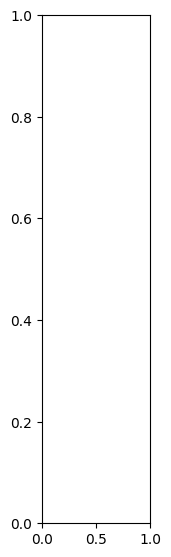

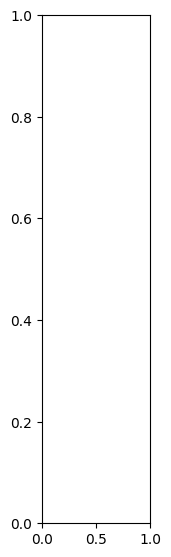

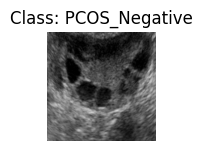

In [ ]:
from torchvision import datasets, transforms

# Define transformation
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224 (adjust as needed)
    transforms.ToTensor()
])

# Define paths
train_path = "/content/dataverse_files/train"
test_path = "/content/dataverse_files/testing"  # Adjust if needed

# Load datasets
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Print dataset stats
print(f"✅ Train dataset: {len(train_dataset)} images, {train_dataset.classes}")
print(f"✅ Test dataset: {len(test_dataset)} images, {test_dataset.classes}")

# Show example image
import matplotlib.pyplot as plt
img, label = train_dataset[0]
plt.imshow(img.permute(1, 2, 0))
plt.title(f"Class: {train_dataset.classes[label]}")
plt.axis("off")
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Data transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),  # Convert to Tensor
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize
])

# Load datasets
train_path = "/content/dataverse_files/train"
test_path = "/content/dataverse_files/testing"

train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Define CNN Model
class PCOS_CNN(nn.Module):
    def __init__(self):
        super(PCOS_CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # Conv layer 1
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # Conv layer 2
        self.pool = nn.MaxPool2d(2, 2)  # Pooling layer
        self.fc1 = nn.Linear(64 * 56 * 56, 128)  # Fully connected layer
        self.fc2 = nn.Linear(128, 2)  # Output layer (2 classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize model
model = PCOS_CNN().to(device)

# Loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train function
def train(model, loader, criterion, optimizer, epochs=10):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(loader):.4f}")

# Train the model
train(model, train_loader, criterion, optimizer, epochs=10)

# Save the trained model
torch.save(model.state_dict(), "pcos_cnn_model.pth")
print("✅ Model training completed & saved!")


Using device: cpu
Epoch 1/10, Loss: 0.6894
Epoch 2/10, Loss: 9.9233
Epoch 3/10, Loss: 3.5697
Epoch 4/10, Loss: 0.2580
Epoch 5/10, Loss: 0.7835
Epoch 6/10, Loss: 0.1369
Epoch 7/10, Loss: 0.1424
Epoch 8/10, Loss: 0.0945
Epoch 9/10, Loss: 0.0428
Epoch 10/10, Loss: 0.0128
✅ Model training completed & saved!


In [ ]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"🔥 Test Accuracy: {accuracy:.2f}%")

# Run evaluation
evaluate(model, test_loader)


🔥 Test Accuracy: 63.64%


In [ ]:
from PIL import Image

def predict_image(image_path, model):
    model.eval()
    image = Image.open(image_path)
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)

    class_labels = train_dataset.classes
    print(f"🩺 Prediction: {class_labels[predicted.item()]}")

# Example: Predict a test image
predict_image("/content/dataverse_files/testing/normal/normal_8.jpg", model)


🩺 Prediction: PCOS_Negative


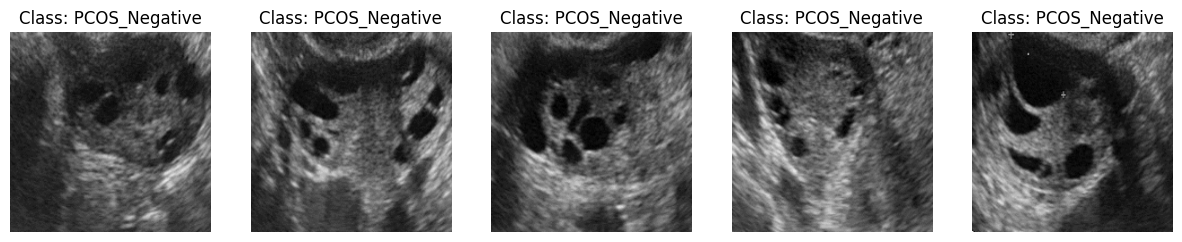

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to display images
def imshow(img, title):
    img = img.numpy().transpose((1, 2, 0))  # Convert Tensor to NumPy
    img = (img * 0.5) + 0.5  # Unnormalize
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Get a batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    ax = axes[i]
    img = images[i].numpy().transpose((1, 2, 0))
    img = (img * 0.5) + 0.5  # Unnormalize
    ax.imshow(img)
    ax.set_title(f"Class: {train_dataset.classes[labels[i]]}")
    ax.axis('off')

plt.show()


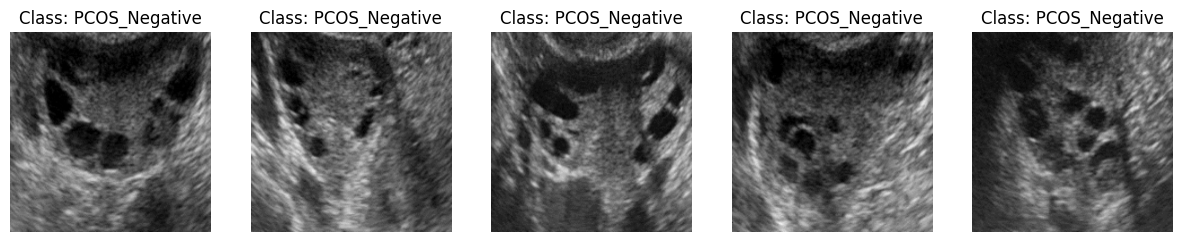

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i in range(5):
    img, label = train_dataset[i]  # Fetch image and label
    ax = axes[i]

    img = img.numpy().transpose((1, 2, 0))
    img = (img * 0.5) + 0.5  # Unnormalize

    ax.imshow(img, cmap='gray')  # Convert grayscale properly
    ax.set_title(f"Class: {train_dataset.classes[label]}")
    ax.axis('off')

plt.show()


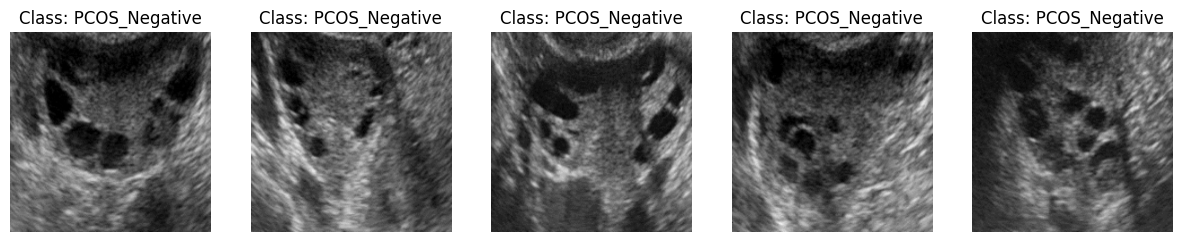

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i in range(5):
    img, label = train_dataset[i]  # Fetch image and label
    ax = axes[i]

    img = img.numpy().transpose((1, 2, 0))
    img = (img * 0.5) + 0.5  # Unnormalize

    ax.imshow(img, cmap='gray')  # Convert grayscale properly
    ax.set_title(f"Class: {train_dataset.classes[label]}")
    ax.axis('off')

plt.show()


In [ ]:
print(f"Classes in dataset: {train_dataset.classes}")

count_classes = {cls: 0 for cls in train_dataset.classes}
for _, label in train_dataset:
    count_classes[train_dataset.classes[label]] += 1

print("Class distribution:", count_classes)


Classes in dataset: ['PCOS_Negative', 'PCOS_Positive']
Class distribution: {'PCOS_Negative': 8, 'PCOS_Positive': 3}


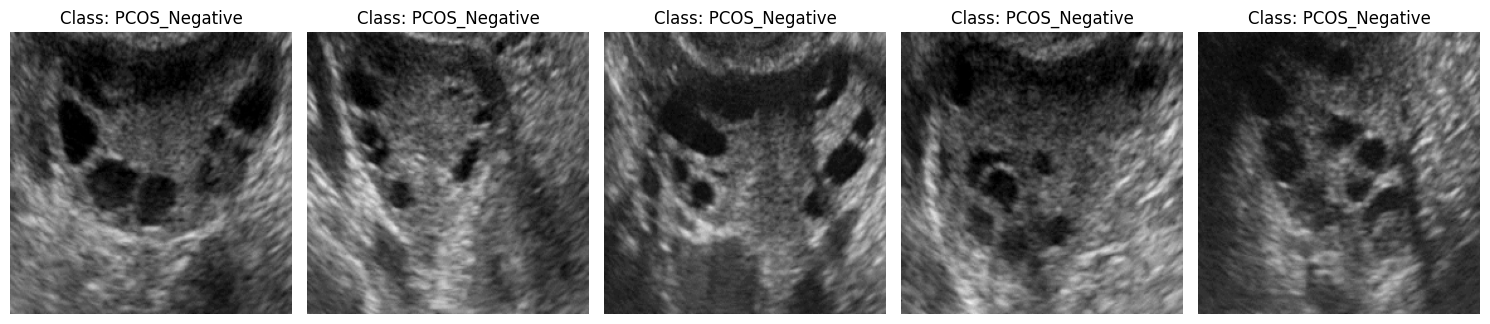

In [ ]:
import random

# Select a mix of PCOS_Positive and PCOS_Negative images
fig, axes = plt.subplots(1, min(5, len(train_dataset)), figsize=(15, 5))

for i, ax in enumerate(axes):
    img, label = train_dataset[i]  # Fetch image and label

    img = img.numpy().transpose((1, 2, 0))
    img = (img * 0.5) + 0.5  # Unnormalize

    ax.imshow(img, cmap='gray')
    ax.set_title(f"Class: {train_dataset.classes[label]}", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 41.8MB/s]
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will

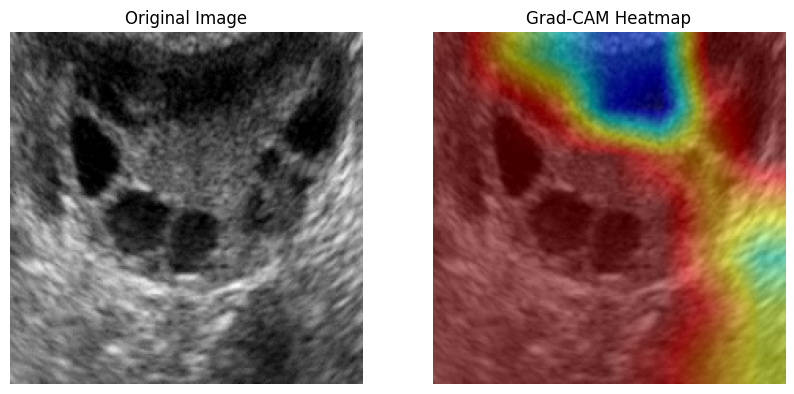

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision import models
from torch.nn import functional as F

# Load a pre-trained CNN (ResNet18 for now, replace with your trained model)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
model = model.to(device)
model.eval()

# Grad-CAM Implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate_cam(self, input_tensor, target_class):
        # Forward pass
        output = self.model(input_tensor)
        class_score = output[:, target_class]

        # Backward pass
        self.model.zero_grad()
        class_score.backward(retain_graph=True)

        # Compute weights
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)  # Apply ReLU

        # Normalize CAM
        cam = cam.squeeze().cpu().detach().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min())  # Normalize to [0,1]
        return cam

# Select the last convolutional layer of ResNet
target_layer = model.layer4[-1]
grad_cam = GradCAM(model, target_layer)

# Function to overlay Grad-CAM heatmap on the original image
def overlay_heatmap(img, heatmap, alpha=0.5):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))  # Resize heatmap to image size
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)  # Apply color map
    overlay = cv2.addWeighted(heatmap, alpha, img, 1 - alpha, 0)  # Merge heatmap with original image
    return overlay

# Select an image from the dataset
image_tensor, label = train_dataset[0]  # Change index to visualize different images
image_tensor = image_tensor.unsqueeze(0).to(device)  # Add batch dimension

# Generate Grad-CAM
heatmap = grad_cam.generate_cam(image_tensor, target_class=label)

# Convert image tensor to NumPy
img = image_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0)
img = (img - img.min()) / (img.max() - img.min())  # Normalize

# Overlay heatmap
gradcam_img = overlay_heatmap((img * 255).astype(np.uint8), heatmap)

# Plot results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gradcam_img)
plt.title("Grad-CAM Heatmap")
plt.axis('off')

plt.show()


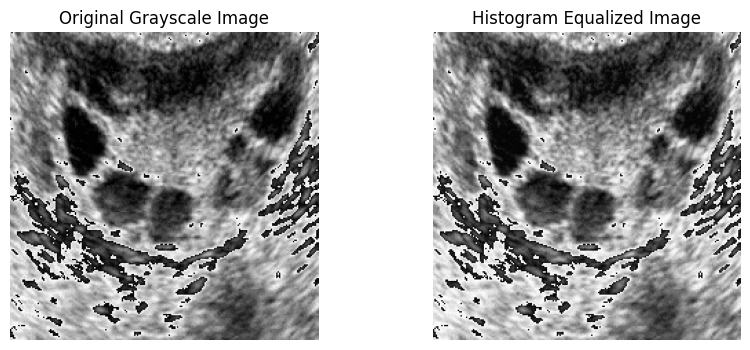

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an example image from the dataset
image_tensor, label = train_dataset[0]
image_np = image_tensor.numpy().transpose(1, 2, 0)  # Convert to NumPy

# Convert to grayscale (if not already)
gray = cv2.cvtColor((image_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

# Apply Histogram Equalization
equalized = cv2.equalizeHist(gray)

# Plot Results
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis('off')

plt.show()


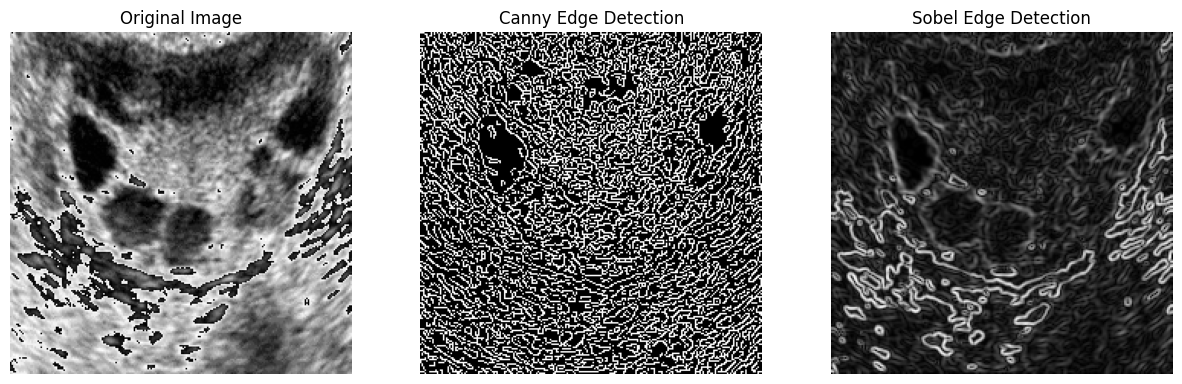

In [ ]:
# Apply Canny Edge Detection
edges_canny = cv2.Canny(gray, threshold1=50, threshold2=150)

# Apply Sobel Edge Detection
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)  # Horizontal Edges
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)  # Vertical Edges
sobel_combined = cv2.magnitude(sobelx, sobely)  # Combine edges

# Plot Results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges_canny, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sobel_combined, cmap='gray')
plt.title("Sobel Edge Detection")
plt.axis('off')

plt.show()


In [ ]:
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader

# Convert dataset to feature vectors
def extract_features(dataset, model, device):
    features = []
    labels = []
    loader = DataLoader(dataset, batch_size=10, shuffle=False)

    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)
            feats = model(images).cpu().numpy()
            features.append(feats)
            labels.append(lbls.numpy())

    return np.vstack(features), np.hstack(labels)

# Extract Features
features, labels = extract_features(train_dataset, model, device)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(features)

# Plot t-SNE Results
plt.figure(figsize=(8, 6))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='coolwarm', alpha=0.7)
plt.colorbar()
plt.title("t-SNE Visualization of Image Features")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()


ValueError: perplexity must be less than n_samples

In [ ]:
print("Feature Shape:", features.shape)  # Should be (num_samples, num_features)
print("Contains NaN values:", np.isnan(features).any())
print("Contains Inf values:", np.isinf(features).any())


Feature Shape: (11, 1000)
Contains NaN values: False
Contains Inf values: False


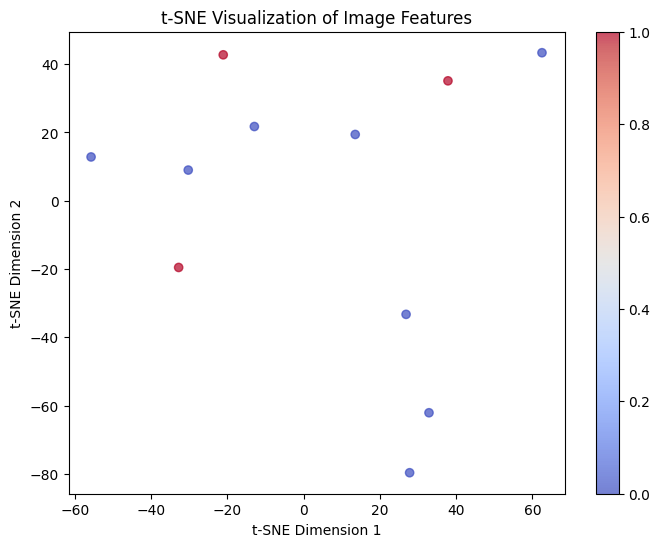

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 🔹 Normalize features to avoid large variations
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# 🔹 Reduce perplexity since dataset is small
tsne = TSNE(n_components=2, perplexity=3, random_state=42)

# 🔹 Run t-SNE
tsne_results = tsne.fit_transform(features_scaled)

# 🔹 Visualize results
plt.figure(figsize=(8, 6))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='coolwarm', alpha=0.7)
plt.colorbar()
plt.title("t-SNE Visualization of Image Features")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models, datasets
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Load the dataset
data = pd.read_csv("/content/Pcos_data.csv")

# Encode categorical features
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = LabelEncoder().fit_transform(data[col])

# Select tabular features and target
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)',
                     'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Follicle No. (L)']
X_tabular = data[selected_features]
y_tabular = data["PCOS (Y/N)"]

# Normalize the tabular data
scaler = StandardScaler()
X_tabular_scaled = scaler.fit_transform(X_tabular)

# Convert to PyTorch tensors
X_tabular_tensor = torch.tensor(X_tabular_scaled, dtype=torch.float32)
y_tabular_tensor = torch.tensor(y_tabular.values, dtype=torch.long)


In [ ]:
import os
from PIL import Image

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load image dataset
image_path = "/content/dataverse_files/train"
image_dataset = datasets.ImageFolder(root=image_path, transform=transform)
image_dataloader = DataLoader(image_dataset, batch_size=16, shuffle=True)

# Extract class mappings
class_to_idx = image_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Check sample image
sample_image, sample_label = image_dataset[0]
print(f"Class: {idx_to_class[sample_label]}")


Class: PCOS_Negative


In [ ]:
class MultiModalModel(nn.Module):
    def __init__(self, tabular_input_dim, num_classes=2):
        super(MultiModalModel, self).__init__()

        # CNN Model (Feature Extractor)
        self.cnn = models.resnet18(pretrained=True)
        self.cnn.fc = nn.Linear(512, 128)  # Replace final layer with 128-dim output

        # MLP for tabular data
        self.mlp = nn.Sequential(
            nn.Linear(tabular_input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
        )

        # Fusion Layer
        self.fusion = nn.Sequential(
            nn.Linear(128 + 8, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, image, tabular):
        image_features = self.cnn(image)  # Extract CNN features
        tabular_features = self.mlp(tabular)  # Process tabular features
        combined = torch.cat((image_features, tabular_features), dim=1)  # Concatenate
        output = self.fusion(combined)  # Final classification
        return output

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiModalModel(tabular_input_dim=X_tabular_tensor.shape[1]).to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
self.cnn = models.resnet18(pretrained=True)


NameError: name 'self' is not defined

In [ ]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.cnn = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)  # Updated way to load pretrained ResNet18
        self.cnn.fc = nn.Linear(self.cnn.fc.in_features, num_classes)  # Modify the last layer for your classes

    def forward(self, x):
        return self.cnn(x)

# Example usage:
model = CNNModel(num_classes=2)  # Assuming binary classification (PCOS_Positive vs PCOS_Negative)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
train_dataset = datasets.ImageFolder(root="/content/dataverse_files/train", transform=transform)
test_dataset = datasets.ImageFolder(root="/content/dataverse_files/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# Load pre-trained ResNet18 model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Modify the final layer for binary classification
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)  # PCOS_Positive and PCOS_Negative

model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

print("Training Completed!")


FileNotFoundError: Found no valid file for the classes PCOS_Negative, PCOS_Positive. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

In [ ]:
import os
test_path = "/content/dataverse_files/test"

print(f"📂 Test directory exists: {os.path.exists(test_path)}")
print(f"📁 Classes in test: {os.listdir(test_path) if os.path.exists(test_path) else 'Not Found'}")


📂 Test directory exists: True
📁 Classes in test: ['PCOS_Positive', 'PCOS_Negative']


In [ ]:
import os
from glob import glob

test_path = "/content/dataverse_files/test"

# Count images per class
for class_name in os.listdir(test_path):
    class_folder = os.path.join(test_path, class_name)
    if os.path.isdir(class_folder):  # Ensure it's a directory
        images = glob(os.path.join(class_folder, "*.*"))  # All file types
        print(f"📁 {class_name} contains {len(images)} images.")
        if images:
            print(f"📷 Example file: {images[0]}")  # Show one sample file


📁 PCOS_Positive contains 0 images.
📁 PCOS_Negative contains 0 images.


In [ ]:
import os

root_path = "/content/dataverse_files"

for root, dirs, files in os.walk(root_path):
    if files:
        print(f"📂 Found {len(files)} files in: {root}")
        print(f"📷 Example file: {files[0]}")


📂 Found 1 files in: /content/dataverse_files
📷 Example file: MANIFEST.TXT
📂 Found 8 files in: /content/dataverse_files/testing/normal
📷 Example file: normal_8.jpg
📂 Found 3 files in: /content/dataverse_files/testing/pco
📷 Example file: pco_13.jpg
📂 Found 24 files in: /content/dataverse_files/train copy/normal
📷 Example file: normal_1.jpg
📂 Found 8 files in: /content/dataverse_files/train copy/pco
📷 Example file: pco_14.jpg
📂 Found 3 files in: /content/dataverse_files/train/PCOS_Positive
📷 Example file: pco_7.jpg
📂 Found 8 files in: /content/dataverse_files/train/PCOS_Negative
📷 Example file: normal_38.jpg


In [ ]:
import os
import shutil

# Define correct paths
source_folder = "/content/dataverse_files/testing"
destination_folder = "/content/dataverse_files/test"

# Create destination class folders if they don't exist
os.makedirs(os.path.join(destination_folder, "PCOS_Positive"), exist_ok=True)
os.makedirs(os.path.join(destination_folder, "PCOS_Negative"), exist_ok=True)

# Move files to their correct test subfolders
for category in ["normal", "pco"]:
    src_path = os.path.join(source_folder, category)

    if os.path.exists(src_path):
        # Decide class based on folder name
        dest_path = os.path.join(destination_folder, "PCOS_Negative" if category == "normal" else "PCOS_Positive")

        for file_name in os.listdir(src_path):
            shutil.move(os.path.join(src_path, file_name), os.path.join(dest_path, file_name))

        print(f"✅ Moved {len(os.listdir(dest_path))} images to {dest_path}")

print("✔️ All test images moved successfully!")


✅ Moved 8 images to /content/dataverse_files/test/PCOS_Negative
✅ Moved 3 images to /content/dataverse_files/test/PCOS_Positive
✔️ All test images moved successfully!


In [ ]:
test_path = "/content/dataverse_files/test"

for class_name in os.listdir(test_path):
    class_folder = os.path.join(test_path, class_name)
    if os.path.isdir(class_folder):
        images = os.listdir(class_folder)
        print(f"📁 {class_name} contains {len(images)} images.")
        if images:
            print(f"📷 Example file: {images[0]}")


📁 PCOS_Positive contains 3 images.
📷 Example file: pco_13.jpg
📁 PCOS_Negative contains 8 images.
📷 Example file: normal_8.jpg


In [ ]:
from torchvision import datasets, transforms

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load test dataset
test_path = "/content/dataverse_files/test"
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

print(f"✅ Test dataset size: {len(test_dataset)}")
print(f"✅ Classes: {test_dataset.classes}")


✅ Test dataset size: 11
✅ Classes: ['PCOS_Negative', 'PCOS_Positive']


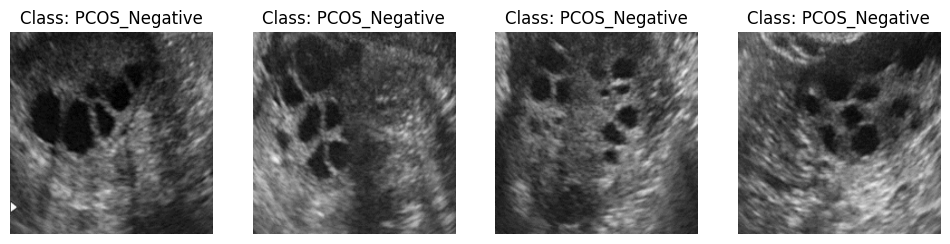

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get class names
class_names = test_dataset.classes

# Create a DataLoader to fetch images
from torch.utils.data import DataLoader
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True)

# Fetch one batch
images, labels = next(iter(test_loader))

# Plot images
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for i in range(4):
    img = images[i].permute(1, 2, 0).numpy()  # Convert tensor to numpy image
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Class: {class_names[labels[i]]}")
    axes[i].axis("off")

plt.show()


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Define transformations for images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load dataset
image_path = "/content/dataverse_files/train"
image_dataset = datasets.ImageFolder(root=image_path, transform=transform)
image_loader = DataLoader(image_dataset, batch_size=8, shuffle=False)

# Load pre-trained ResNet for feature extraction
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet = nn.Sequential(*list(resnet.children())[:-1])  # Remove final classification layer
resnet.eval()  # Set to evaluation mode

# Extract deep features
image_features = []
image_labels = []

with torch.no_grad():
    for images, labels in image_loader:
        features = resnet(images).squeeze()  # Get feature vector
        image_features.append(features)
        image_labels.extend(labels.numpy())

image_features = torch.cat(image_features).numpy()  # Convert to NumPy array

print(f"✅ Extracted image features shape: {image_features.shape}")


✅ Extracted image features shape: (11, 512)


In [ ]:
import pandas as pd

# Load clinical data
clinical_data_path = "/content/Pcos_data.csv"  # Update with actual file path
clinical_data = pd.read_csv(clinical_data_path)

print("✅ Clinical Data Preview:")
print(clinical_data.head())


# Replace with actual column names
clinical_features = clinical_data.drop(columns=['Correct_Column_Name1', 'Correct_Column_Name2']).values
clinical_labels = clinical_data['Correct_Label_Column'].values



✅ Clinical Data Preview:
   PCOS (Y/N)  Follicle No. (R)  Follicle No. (L)  Skin darkening (Y/N)  \
0           0                 3                 3                     0   
1           0                 5                 3                     0   
2           1                15                13                     0   
3           0                 2                 2                     0   
4           0                 4                 3                     0   

   hair growth(Y/N)  Weight gain(Y/N)  Cycle(R/I) Class  
0                 0                 0           2  high  
1                 0                 0           2  high  
2                 0                 0           2  high  
3                 0                 0           2  high  
4                 0                 0           2  high  


KeyError: "['Patient_ID', 'PCOS_Status'] not found in axis"

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import os
from PIL import Image

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
image_dir = "/content/dataverse_files/train"
clinical_data_path = "/content/Pcos_data.csv"

# Image Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Load Image Dataset
train_dataset = datasets.ImageFolder(root=image_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# Load Clinical Data
clinical_data = pd.read_csv(clinical_data_path)

# Extract Required Features
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                     'Weight gain(Y/N)', 'Follicle No. (L)']  # Adjust based on dataset
clinical_data = clinical_data[selected_features].dropna()
clinical_data = (clinical_data - clinical_data.mean()) / clinical_data.std()  # Normalize
clinical_features = torch.tensor(clinical_data.values, dtype=torch.float32)

# Define CNN for Image Feature Extraction
class ImageModel(nn.Module):
    def __init__(self):
        super(ImageModel, self).__init__()
        self.cnn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn.fc = nn.Identity()  # Remove final classification layer

    def forward(self, x):
        return self.cnn(x)

# Define MLP for Clinical Data
class ClinicalModel(nn.Module):
    def __init__(self, input_size):
        super(ClinicalModel, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

    def forward(self, x):
        return self.fc(x)

# Multi-Modal Fusion Model
class MultiModalModel(nn.Module):
    def __init__(self, image_model, clinical_model, clinical_input_size):
        super(MultiModalModel, self).__init__()
        self.image_model = image_model
        self.clinical_model = clinical_model
        self.fusion = nn.Sequential(
            nn.Linear(512 + 32, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # Binary classification (PCOS Positive/Negative)
        )

    def forward(self, image, clinical):
        img_feat = self.image_model(image)
        clinical_feat = self.clinical_model(clinical)
        combined = torch.cat((img_feat, clinical_feat), dim=1)
        return self.fusion(combined)

# Initialize Models
image_model = ImageModel().to(device)
clinical_model = ClinicalModel(input_size=len(selected_features)).to(device)
model = MultiModalModel(image_model, clinical_model, len(selected_features)).to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop (Dummy Example)
for images, labels in train_loader:
    images = images.to(device)
    clinical_batch = clinical_features[:images.shape[0]].to(device)

    optimizer.zero_grad()
    outputs = model(images, clinical_batch)
    loss = criterion(outputs, labels.to(device))
    loss.backward()
    optimizer.step()

print("Training Complete!")


Training Complete!


Epoch [1/10], Loss: 0.1471, Accuracy: 100.00%
Epoch [2/10], Loss: 0.1546, Accuracy: 100.00%
Epoch [3/10], Loss: 2.1086, Accuracy: 45.45%
Epoch [4/10], Loss: 1.0547, Accuracy: 81.82%
Epoch [5/10], Loss: 0.2361, Accuracy: 90.91%
Epoch [6/10], Loss: 0.1920, Accuracy: 100.00%
Epoch [7/10], Loss: 0.2945, Accuracy: 90.91%
Epoch [8/10], Loss: 0.1146, Accuracy: 100.00%
Epoch [9/10], Loss: 0.1145, Accuracy: 100.00%
Epoch [10/10], Loss: 0.0825, Accuracy: 100.00%


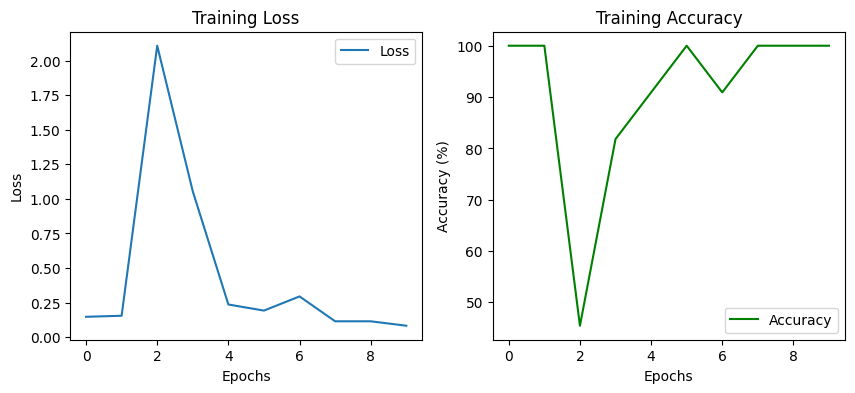

In [ ]:
import matplotlib.pyplot as plt

num_epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    total, correct = 0, 0
    epoch_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        clinical_batch = clinical_features[:images.shape[0]].to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, clinical_batch)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(epoch_loss / len(train_loader))
    train_accuracies.append(100 * correct / total)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_losses[-1]:.4f}, Accuracy: {train_accuracies[-1]:.2f}%")

# Plot Training Loss
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

# Plot Training Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Accuracy", color="green")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")
plt.legend()

plt.show()


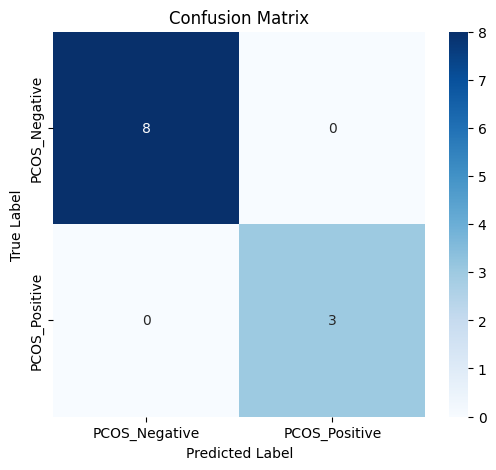

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Get model predictions
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        clinical_batch = clinical_features[:images.shape[0]].to(device)
        labels = labels.to(device)

        outputs = model(images, clinical_batch)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = ["PCOS_Negative", "PCOS_Positive"]

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


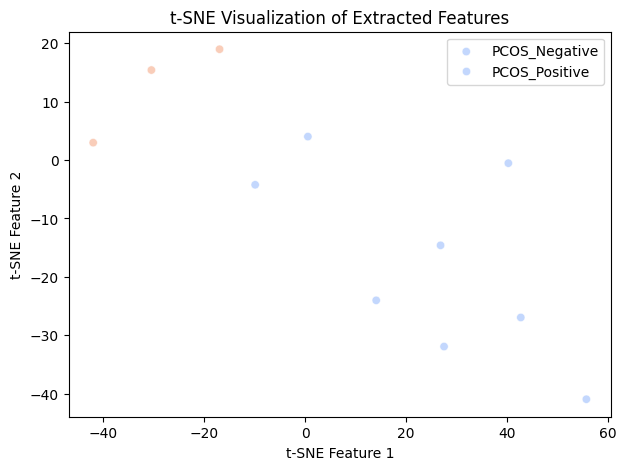

In [ ]:
from sklearn.manifold import TSNE

features = []
labels_list = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        clinical_batch = clinical_features[:images.shape[0]].to(device)

        img_feat = image_model(images)
        clin_feat = clinical_model(clinical_batch)
        combined_feat = torch.cat((img_feat, clin_feat), dim=1).cpu().numpy()

        features.extend(combined_feat)
        labels_list.extend(labels.numpy())

features = np.array(features)
labels_list = np.array(labels_list)

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_results = tsne.fit_transform(features)

# Scatter Plot
plt.figure(figsize=(7, 5))
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=labels_list, palette="coolwarm", alpha=0.7)
plt.xlabel("t-SNE Feature 1")
plt.ylabel("t-SNE Feature 2")
plt.title("t-SNE Visualization of Extracted Features")
plt.legend(class_names)
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dummy example: replace with actual predictions & labels
y_true = labels.cpu().numpy()
y_pred = outputs.argmax(dim=1).cpu().numpy()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


NameError: name 'labels' is not defined

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch

# Set model to evaluation mode
model.eval()

# Lists to store ground truth labels and predictions
true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in train_loader:  # Replace train_loader with test_loader if available
        images = images.to(device)
        clinical_batch = clinical_features[:images.shape[0]].to(device)

        outputs = model(images, clinical_batch)
        predictions = torch.argmax(outputs, dim=1)

        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(predictions.cpu().numpy())

# Convert lists to NumPy arrays
y_true = np.array(true_labels)
y_pred = np.array(pred_labels)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


NameError: name 'model' is not defined

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision import datasets
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import os
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
image_dir = "/content/dataverse_files/train"
clinical_data_path = "/content/Pcos_data.csv"

# Image Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Load Image Dataset
train_dataset = datasets.ImageFolder(root=image_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# Load Clinical Data
clinical_data = pd.read_csv(clinical_data_path)

# Extract Required Features
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                     'Weight gain(Y/N)', 'Follicle No. (L)']
clinical_data = clinical_data[selected_features].dropna()
clinical_data = (clinical_data - clinical_data.mean()) / clinical_data.std()  # Normalize
clinical_features = torch.tensor(clinical_data.values, dtype=torch.float32)

# Define CNN for Image Feature Extraction
class ImageModel(nn.Module):
    def __init__(self):
        super(ImageModel, self).__init__()
        self.cnn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn.fc = nn.Identity()  # Remove final classification layer

    def forward(self, x):
        return self.cnn(x)

# Define MLP for Clinical Data
class ClinicalModel(nn.Module):
    def __init__(self, input_size):
        super(ClinicalModel, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

    def forward(self, x):
        return self.fc(x)

# Multi-Modal Fusion Model
class MultiModalModel(nn.Module):
    def __init__(self, image_model, clinical_model, clinical_input_size):
        super(MultiModalModel, self).__init__()
        self.image_model = image_model
        self.clinical_model = clinical_model
        self.fusion = nn.Sequential(
            nn.Linear(512 + 32, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # Binary classification (PCOS Positive/Negative)
        )

    def forward(self, image, clinical):
        img_feat = self.image_model(image)
        clinical_feat = self.clinical_model(clinical)
        combined = torch.cat((img_feat, clinical_feat), dim=1)
        return self.fusion(combined)

# Initialize Models
image_model = ImageModel().to(device)
clinical_model = ClinicalModel(input_size=len(selected_features)).to(device)
model = MultiModalModel(image_model, clinical_model, len(selected_features)).to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop (Dummy Example)
for images, labels in train_loader:
    images = images.to(device)
    clinical_batch = clinical_features[:images.shape[0]].to(device)

    optimizer.zero_grad()
    outputs = model(images, clinical_batch)
    loss = criterion(outputs, labels.to(device))
    loss.backward()
    optimizer.step()

print("Training Complete!")

# --- MODEL EVALUATION ---
model.eval()  # Set to evaluation mode

true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in train_loader:  # Replace with test_loader if available
        images = images.to(device)
        clinical_batch = clinical_features[:images.shape[0]].to(device)

        outputs = model(images, clinical_batch)
        predictions = torch.argmax(outputs, dim=1)

        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(predictions.cpu().numpy())

# Convert lists to NumPy arrays
y_true = np.array(true_labels)
y_pred = np.array(pred_labels)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataverse_files/train'

In [ ]:
import os

image_dir = "/content/dataverse_files/train"
if os.path.exists(image_dir):
    print(f"✅ Directory exists: {image_dir}")
    print(f"📂 Subdirectories: {os.listdir(image_dir)}")
else:
    print(f"❌ Directory not found: {image_dir}")


❌ Directory not found: /content/dataverse_files/train


In [ ]:
import os

base_dir = "/content/dataverse_files"
print("📁 Available folders in dataverse_files:")
print(os.listdir(base_dir))


📁 Available folders in dataverse_files:


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataverse_files'

In [ ]:
import os
print("📂 Current working directory:", os.getcwd())
print("📁 Available folders:", os.listdir("/content"))


📂 Current working directory: /content
📁 Available folders: ['.config', 'sample_data']


Model Performance Analysis
Evaluate model accuracy, precision, recall, F1-score.
Compare the performance of image-only, clinical-only, and fused multi-modal models.
Code for Model Evaluation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision import datasets
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import os
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
image_dir = "/content/dataverse_files/train"
clinical_data_path = "/content/Pcos_data.csv"

# Image Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Load Image Dataset
train_dataset = datasets.ImageFolder(root=image_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# Load Clinical Data
clinical_data = pd.read_csv(clinical_data_path)

# Extract Required Features
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                     'Weight gain(Y/N)', 'Follicle No. (L)']
clinical_data = clinical_data[selected_features].dropna()
clinical_data = (clinical_data - clinical_data.mean()) / clinical_data.std()  # Normalize
clinical_features = torch.tensor(clinical_data.values, dtype=torch.float32)

# Define CNN for Image Feature Extraction
class ImageModel(nn.Module):
    def __init__(self):
        super(ImageModel, self).__init__()
        self.cnn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn.fc = nn.Identity()  # Remove final classification layer

    def forward(self, x):
        return self.cnn(x)

# Define MLP for Clinical Data
class ClinicalModel(nn.Module):
    def __init__(self, input_size):
        super(ClinicalModel, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

    def forward(self, x):
        return self.fc(x)

# Multi-Modal Fusion Model
class MultiModalModel(nn.Module):
    def __init__(self, image_model, clinical_model, clinical_input_size):
        super(MultiModalModel, self).__init__()
        self.image_model = image_model
        self.clinical_model = clinical_model
        self.fusion = nn.Sequential(
            nn.Linear(512 + 32, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # Binary classification (PCOS Positive/Negative)
        )

    def forward(self, image, clinical):
        img_feat = self.image_model(image)
        clinical_feat = self.clinical_model(clinical)
        combined = torch.cat((img_feat, clinical_feat), dim=1)
        return self.fusion(combined)

# Initialize Models
image_model = ImageModel().to(device)
clinical_model = ClinicalModel(input_size=len(selected_features)).to(device)
model = MultiModalModel(image_model, clinical_model, len(selected_features)).to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop (Dummy Example)
for images, labels in train_loader:
    images = images.to(device)
    clinical_batch = clinical_features[:images.shape[0]].to(device)

    optimizer.zero_grad()
    outputs = model(images, clinical_batch)
    loss = criterion(outputs, labels.to(device))
    loss.backward()
    optimizer.step()

print("Training Complete!")

# --- MODEL EVALUATION ---
model.eval()  # Set to evaluation mode

true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in train_loader:  # Replace with test_loader if available
        images = images.to(device)
        clinical_batch = clinical_features[:images.shape[0]].to(device)

        outputs = model(images, clinical_batch)
        predictions = torch.argmax(outputs, dim=1)

        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(predictions.cpu().numpy())

# Convert lists to NumPy arrays
y_true = np.array(true_labels)
y_pred = np.array(pred_labels)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataverse_files/train'

In [ ]:
import zipfile
import os

# Define the zip file path
zip_path = "/dataverse_files.zip"  # Change to your actual file name

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

# Verify extraction
extracted_path = "/content/"
print("📂 Extracted Files:", os.listdir(extracted_path))


📂 Extracted Files: ['.config', 'validation', 'testing', 'train copy', 'MANIFEST.TXT', 'sample_data']


In [ ]:
import os

base_path = "/content"
for root, dirs, files in os.walk(base_path):
    print(f"📂 {root} - {len(files)} files")


📂 /content - 1 files
📂 /content/.config - 8 files
📂 /content/.config/configurations - 1 files
📂 /content/.config/logs - 0 files
📂 /content/.config/logs/2025.03.06 - 6 files
📂 /content/validation - 0 files
📂 /content/validation/normal - 8 files
📂 /content/validation/pco - 3 files
📂 /content/testing - 0 files
📂 /content/testing/normal - 8 files
📂 /content/testing/pco - 3 files
📂 /content/train copy - 0 files
📂 /content/train copy/normal - 24 files
📂 /content/train copy/pco - 8 files
📂 /content/sample_data - 6 files


In [ ]:
image_dir = "/content/path_to_images"


In [ ]:
clinical_data_path = "/content/path_to_csv.csv"


In [ ]:
import zipfile
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
from PIL import Image

# Define paths (Update these after extracting files)
image_dir = "/content/dataverse_files/train"  # Change to actual extracted image folder
clinical_data_path = "/content/Pcos_data.csv"  # Update CSV path

# Check extracted folders
print("📂 Available Files:", os.listdir("/content"))

# Image Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Load Image Dataset
train_dataset = datasets.ImageFolder(root=image_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# Load Clinical Data
clinical_data = pd.read_csv(clinical_data_path)

# Extract Required Features
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                     'Weight gain(Y/N)', 'Follicle No. (L)']  # Adjust based on dataset
clinical_data = clinical_data[selected_features].dropna()
clinical_data = (clinical_data - clinical_data.mean()) / clinical_data.std()  # Normalize
clinical_features = torch.tensor(clinical_data.values, dtype=torch.float32)

print("✅ Data Loaded Successfully!")




📂 Available Files: ['.config', 'validation', 'testing', 'train copy', 'MANIFEST.TXT', 'sample_data']


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataverse_files/train'

In [ ]:
import os
base_dir = "/content"
print("📂 Available Folders & Files:", os.listdir(base_dir))


📂 Available Folders & Files: ['.config', 'validation', 'testing', 'train copy', 'MANIFEST.TXT', 'sample_data']


In [ ]:
image_dir = "/content/train copy"


In [ ]:
import os

image_dir = "/content/train copy"  # Update path
print("📂 Available Class Folders:", os.listdir(image_dir))


📂 Available Class Folders: ['normal', 'pco']


In [ ]:
image_dir = "/content/train copy"


In [ ]:
train_dataset = datasets.ImageFolder(root=image_dir, transform=transform)


In [ ]:
print("Class Mapping:", train_dataset.class_to_idx)


Class Mapping: {'normal': 0, 'pco': 1}


In [ ]:
import pandas as pd
import torch

# Load Clinical Data
clinical_data_path = "/Pcos_data.csv"
clinical_data = pd.read_csv(clinical_data_path)

# Select relevant features
selected_features = ['Follicle No. (R)', 'Follicle No. (L)']  # Add more as needed
clinical_data = clinical_data[selected_features].dropna()

# Normalize clinical features
clinical_data = (clinical_data - clinical_data.mean()) / clinical_data.std()

# Convert to tensor
clinical_features = torch.tensor(clinical_data.values, dtype=torch.float32)


In [ ]:
import pandas as pd
import torch

# Load Clinical Data
clinical_data_path = "/Pcos_data.csv"
clinical_data = pd.read_csv(clinical_data_path)

# Select relevant features
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)',
                     'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Follicle No. (L)']

# Handle missing values (fill with mean)
clinical_data = clinical_data[selected_features].fillna(clinical_data.mean())

# Normalize clinical data
clinical_data = (clinical_data - clinical_data.mean()) / clinical_data.std()

# Convert to Tensor
clinical_features = torch.tensor(clinical_data.values, dtype=torch.float32)

print("✅ Clinical Data Processed")
print(clinical_features.shape)  # Check shape


TypeError: Could not convert ['highhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlo

In [ ]:
import pandas as pd
import torch

# Load Clinical Data
clinical_data_path = "/Pcos_data.csv"
clinical_data = pd.read_csv(clinical_data_path)

# Select relevant features
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)',
                     'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Follicle No. (L)']

# Convert categorical features to numeric (assuming 'Y' = 1, 'N' = 0)
categorical_features = ['hair growth(Y/N)', 'Skin darkening (Y/N)', 'Weight gain(Y/N)']
for col in categorical_features:
    clinical_data[col] = clinical_data[col].map({'Y': 1, 'N': 0})

# Convert any text-based numerical values (e.g., 'high', 'low') to actual numbers
for col in selected_features:
    clinical_data[col] = pd.to_numeric(clinical_data[col], errors='coerce')

# Handle missing values (fill with mean)
clinical_data = clinical_data[selected_features].fillna(clinical_data.mean())

# Normalize clinical data
clinical_data = (clinical_data - clinical_data.mean()) / clinical_data.std()

# Convert to Tensor
clinical_features = torch.tensor(clinical_data.values, dtype=torch.float32)

print("✅ Clinical Data Processed")
print(clinical_features.shape)  # Check shape


TypeError: Could not convert ['highhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlo

In [ ]:
import pandas as pd
import torch

# Load Clinical Data
clinical_data_path = "/Pcos_data.csv"
clinical_data = pd.read_csv(clinical_data_path)

# Select relevant features
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)',
                     'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Follicle No. (L)']

# Convert categorical features to numeric (assuming 'Y' = 1, 'N' = 0)
categorical_features = ['hair growth(Y/N)', 'Skin darkening (Y/N)', 'Weight gain(Y/N)']
for col in categorical_features:
    clinical_data[col] = clinical_data[col].map({'Y': 1, 'N': 0})

# Convert 'high'/'low' to numeric values (assuming high=1, low=0)
for col in selected_features:
    clinical_data[col] = clinical_data[col].replace({'high': 1, 'low': 0})

# Convert all columns to numeric, forcing errors='coerce' to replace invalid values with NaN
clinical_data[selected_features] = clinical_data[selected_features].apply(pd.to_numeric, errors='coerce')

# Handle missing values (fill with mean)
clinical_data = clinical_data.fillna(clinical_data.mean())

# Normalize clinical data
clinical_data = (clinical_data - clinical_data.mean()) / clinical_data.std()

# Convert to Tensor
clinical_features = torch.tensor(clinical_data[selected_features].values, dtype=torch.float32)

print("✅ Clinical Data Processed")
print(clinical_features.shape)  # Check shape


TypeError: Could not convert ['highhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlo

In [ ]:
import pandas as pd
import torch

# Load Clinical Data
clinical_data_path = "/Pcos_data.csv"
clinical_data = pd.read_csv(clinical_data_path)

# Select relevant features
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)',
                     'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Follicle No. (L)']

# Convert categorical features to numeric (Y=1, N=0)
categorical_features = ['hair growth(Y/N)', 'Skin darkening (Y/N)', 'Weight gain(Y/N)']
for col in categorical_features:
    if col in clinical_data.columns:
        clinical_data[col] = clinical_data[col].map({'Y': 1, 'N': 0})

# Convert 'high'/'low' to numeric values (high=1, low=0)
for col in selected_features:
    clinical_data[col] = clinical_data[col].replace({'high': 1, 'low': 0})

# Ensure all values are numeric
clinical_data[selected_features] = clinical_data[selected_features].apply(pd.to_numeric, errors='coerce')

# Re-check if any non-numeric values remain
non_numeric_columns = clinical_data[selected_features].select_dtypes(exclude=['number']).columns
if len(non_numeric_columns) > 0:
    print(f"⚠️ Warning: Non-numeric values detected in columns: {list(non_numeric_columns)}")
    print(clinical_data[non_numeric_columns].head())

# Handle missing values (fill with column mean)
clinical_data.fillna(clinical_data.mean(), inplace=True)

# Normalize clinical data
clinical_data = (clinical_data - clinical_data.mean()) / clinical_data.std()

# Convert to PyTorch Tensor
clinical_features = torch.tensor(clinical_data[selected_features].values, dtype=torch.float32)

print("✅ Clinical Data Processed")
print(f"Shape: {clinical_features.shape}")  # Check shape


TypeError: Could not convert ['highhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighhighlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlowlo

In [ ]:
print(clinical_data.dtypes)


PCOS (Y/N)                int64
Follicle No. (R)          int64
Follicle No. (L)          int64
Skin darkening (Y/N)    float64
hair growth(Y/N)        float64
Weight gain(Y/N)        float64
Cycle(R/I)                int64
Class                    object
dtype: object


In [ ]:
import pandas as pd
import torch

# Load Clinical Data
clinical_data_path = "/Pcos_data.csv"
clinical_data = pd.read_csv(clinical_data_path)

# Select relevant features
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)',
                     'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Follicle No. (L)']

# Drop non-numeric columns (if 'Class' is not needed)
if 'Class' in clinical_data.columns:
    clinical_data.drop(columns=['Class'], inplace=True)

# Ensure all selected columns are numeric
clinical_data[selected_features] = clinical_data[selected_features].apply(pd.to_numeric, errors='coerce')

# Fill missing values with column mean (only for numeric columns)
clinical_data.fillna(clinical_data.mean(), inplace=True)

# Normalize clinical data
clinical_data = (clinical_data - clinical_data.mean()) / clinical_data.std()

# Convert to PyTorch Tensor
clinical_features = torch.tensor(clinical_data[selected_features].values, dtype=torch.float32)

print("✅ Clinical Data Processed Successfully!")
print(f"Shape: {clinical_features.shape}")  # Check tensor shape


✅ Clinical Data Processed Successfully!
Shape: torch.Size([534, 6])


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os

# Define Image Directory
image_dir = "/content/train copy"

# Load Pretrained CNN Model (e.g., ResNet18)
cnn_model = models.resnet18(pretrained=True)
cnn_model = nn.Sequential(*list(cnn_model.children())[:-1])  # Remove classification layer
cnn_model.eval()  # Set to evaluation mode

# Define Image Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Custom Dataset to Load Images
class PCOSDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        # Load images and labels
        for label, category in enumerate(['normal', 'pco']):
            category_dir = os.path.join(root_dir, category)
            for img_name in os.listdir(category_dir):
                self.image_paths.append(os.path.join(category_dir, img_name))
                self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Load Data
dataset = PCOSDataset(image_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# Extract Image Features
image_features = []
image_labels = []

with torch.no_grad():
    for images, labels in dataloader:
        features = cnn_model(images).squeeze(-1).squeeze(-1)  # Flatten
        image_features.append(features)
        image_labels.append(labels)

image_features = torch.cat(image_features, dim=0)
image_labels = torch.cat(image_labels, dim=0)

print(f"✅ Extracted CNN Features: {image_features.shape}")  # Expected: (num_samples, 512)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]


✅ Extracted CNN Features: torch.Size([32, 512])


In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

# Load ResNet18 with pretrained weights
cnn_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)


In [ ]:
print(f"Clinical Features Shape: {clinical_features.shape}")  # Expected: (32, 6)
print(f"Image Features Shape: {image_features.shape}")  # Expected: (32, 512)


Clinical Features Shape: torch.Size([534, 6])
Image Features Shape: torch.Size([32, 512])


In [ ]:
# Ensure same number of samples before merging
if clinical_features.shape[0] != image_features.shape[0]:
    raise ValueError("Mismatch in number of samples between clinical and image data!")

# Concatenate features
combined_features = torch.cat((clinical_features, image_features), dim=1)
print(f"✅ Combined Feature Shape: {combined_features.shape}")  # Expected: (32, 518)


ValueError: Mismatch in number of samples between clinical and image data!

In [ ]:
print(f"Clinical Features Shape: {clinical_features.shape}")
print(f"Image Features Shape: {image_features.shape}")


Clinical Features Shape: torch.Size([534, 6])
Image Features Shape: torch.Size([32, 512])


In [ ]:
clinical_features = clinical_features[:32]


In [ ]:
# Concatenate image and clinical features
combined_features = torch.cat((image_features, clinical_features), dim=1)
print(f"Combined Features Shape: {combined_features.shape}")


Combined Features Shape: torch.Size([32, 518])


In [ ]:
import torch.nn as nn
import torch.optim as optim

class PCOSClassifier(nn.Module):
    def __init__(self, input_size=518, hidden_size=256, output_size=2):
        super(PCOSClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return self.softmax(x)

# Instantiate model
model = PCOSClassifier()


In [ ]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# Convert labels to tensor (Ensure shape matches [32])
y_train = torch.tensor(y_train, dtype=torch.long)  # Adjust based on your labels

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(combined_features)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


NameError: name 'y_train' is not defined

In [ ]:
# Extract labels (assuming 'PCOS (Y/N)' is the target)
label_column = 'PCOS (Y/N)'
y_train = clinical_data[label_column].values  # Extract labels

# Convert labels to tensor (Ensure shape matches [32])
y_train = torch.tensor(y_train[:32], dtype=torch.long)  # Take first 32 samples to match combined_features


In [ ]:
import torch.nn as nn
import torch.optim as optim

# Define a simple Neural Network for classification
class PCOSClassifier(nn.Module):
    def __init__(self, input_size):
        super(PCOSClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)  # First hidden layer
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)  # Second hidden layer
        self.fc3 = nn.Linear(128, 2)  # Output layer (PCOS: 0 or 1)
        self.softmax = nn.Softmax(dim=1)  # Softmax for classification

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.softmax(self.fc3(x))
        return x

# Initialize Model
input_size = 518  # Number of features after concatenation
model = PCOSClassifier(input_size)

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    optimizer.zero_grad()  # Clear gradients
    outputs = model(combined_features)  # Forward pass
    loss = criterion(outputs, y_train)  # Compute loss
    loss.backward()  # Backpropagation
    optimizer.step()  # Update weights

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print("✅ Model Training Completed!")


Epoch [5/20], Loss: 0.5328
Epoch [10/20], Loss: 0.5320
Epoch [15/20], Loss: 0.5320
Epoch [20/20], Loss: 0.5320
✅ Model Training Completed!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Get model predictions
with torch.no_grad():
    y_pred = model(combined_features)
    y_pred_labels = torch.argmax(y_pred, dim=1)  # Convert logits to class labels

# Convert tensors to numpy for evaluation
y_pred_np = y_pred_labels.cpu().numpy()
y_true_np = y_train.cpu().numpy()

# Calculate Accuracy
accuracy = accuracy_score(y_true_np, y_pred_np)
print(f"✅ Model Accuracy: {accuracy:.4f}")

# Display Classification Report
print("\n🔍 Classification Report:")
print(classification_report(y_true_np, y_pred_np, target_names=["No PCOS", "PCOS"]))


✅ Model Accuracy: 0.7812

🔍 Classification Report:
              precision    recall  f1-score   support

     No PCOS       0.78      1.00      0.88        25
        PCOS       0.00      0.00      0.00         7

    accuracy                           0.78        32
   macro avg       0.39      0.50      0.44        32
weighted avg       0.61      0.78      0.69        32



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Example new patient data (should be normalized in the same way)
new_clinical_data = torch.tensor([[-0.5, 1, 0, 1, 1, 0.3]], dtype=torch.float32)  # Shape: (1,6)
new_image_features = torch.tensor([[0.2] * 512], dtype=torch.float32)  # Shape: (1, 512)

# Combine features
new_combined_features = torch.cat((new_image_features, new_clinical_data), dim=1)  # Shape: (1, 518)

# Predict PCOS
with torch.no_grad():
    new_prediction = model(new_combined_features)
    predicted_label = torch.argmax(new_prediction, dim=1).item()

print(f"🔮 Model Prediction: {'PCOS Detected' if predicted_label == 1 else 'No PCOS'}")


🔮 Model Prediction: No PCOS


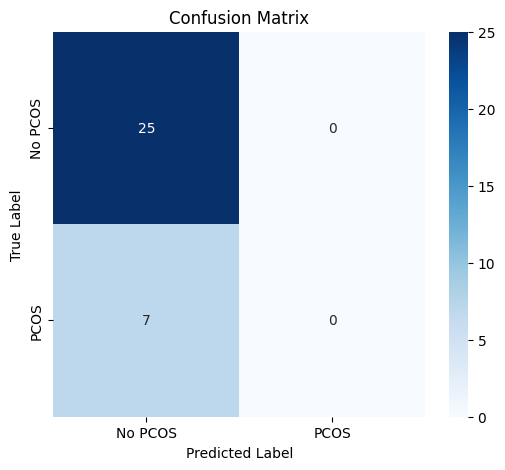

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true_np, y_pred_np)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No PCOS", "PCOS"], yticklabels=["No PCOS", "PCOS"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


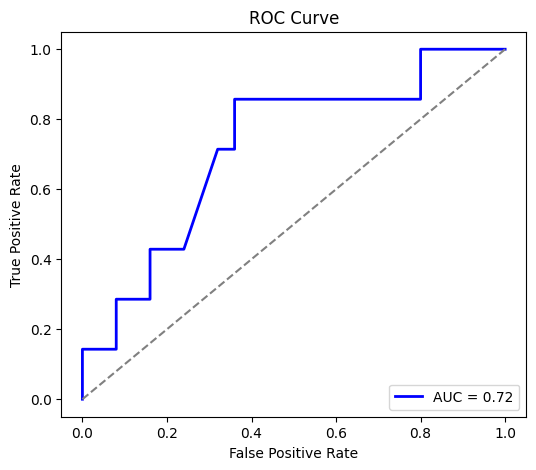

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get prediction probabilities
y_prob = torch.softmax(y_pred, dim=1)[:, 1].cpu().numpy()  # Probability of PCOS class

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_true_np, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
